## Sentence Convergence w/ NLP Scaled

In [11]:
# === Explode keeping natural order + diagnostics ===
import re
import numpy as np
import pandas as pd
from tqdm import tqdm

_SENT_SPLIT = re.compile(r'(?<=[\.\!\?])\s+(?=[A-Z0-9\"\'\(\[])')

def split_utterance(utter: str) -> list[str]:
    if not isinstance(utter, str) or not utter.strip():
        return []
    sents = [s.strip() for s in _SENT_SPLIT.split(utter.strip()) if s.strip()]
    return sents if sents else [utter.strip()]

def explode_to_sentences_like_template(
    df_utt: pd.DataFrame,
    template_cols: list[str] | None = None
) -> pd.DataFrame:
    df_utt = df_utt.copy()
    # Preserve original input order
    if "_utter_row" not in df_utt.columns:
        df_utt["_utter_row"] = np.arange(len(df_utt))

    rows = []
    for _, r in tqdm(df_utt.iterrows(), total=len(df_utt), desc="Exploding to sentences"):
        utter = str(r.get("transcript", "") or "").strip()
        if not utter:
            continue

        sents = split_utterance(utter)
        start = r.get("start_sec_adjusted", np.nan)
        end   = r.get("end_sec_adjusted", np.nan)

        used_fallback = False
        if pd.isna(start) or pd.isna(end) or float(end) <= float(start):
            center = float(r.get("global_timestamp_sec", np.nan))
            sent_starts = [center] * len(sents)
            sent_ends   = [center] * len(sents)
            used_fallback = True
        else:
            dur = float(end - start)
            lens = np.array([max(1, len(s)) for s in sents], dtype=float)
            weights = lens / lens.sum()
            seg_durs = dur * weights
            midpoints = float(start) + np.cumsum(seg_durs) - seg_durs / 2.0
            sent_starts = (midpoints - seg_durs / 2.0).tolist()
            sent_ends   = (midpoints + seg_durs / 2.0).tolist()

        annotations   = r.get("annotations", "")
        session_core  = r.get("session_core", np.nan)
        global_sess   = r.get("global_session", np.nan)
        global_time   = r.get("global_timestamp_sec", np.nan)

        for j, (s, t0, t1) in enumerate(zip(sents, sent_starts, sent_ends)):
            rows.append({
                # identity
                "conference": r.get("conference"),
                "session": r.get("session"),
                "session_core": session_core,
                "global_session": global_sess,
                "speaker": r.get("speaker"),

                # natural order keys
                "_utter_row": int(r["_utter_row"]),
                "_sent_idx": int(j),

                # sentence + times
                "sentence": s,
                "sent_start_sec_est": float(t0) if pd.notna(t0) else np.nan,
                "sent_end_sec_est": float(t1) if pd.notna(t1) else np.nan,
                "sent_time_sec": float((t0 + t1) / 2.0) if (pd.notna(t0) and pd.notna(t1)) else float(t0),

                # overlays
                "annotations": annotations,

                # convenience + diagnostics
                "global_timestamp_sec": float(global_time) if pd.notna(global_time) else np.nan,
                "_used_fallback_time": bool(used_fallback),
                "_parent_start_sec": float(start) if pd.notna(start) else np.nan,
                "_parent_end_sec": float(end) if pd.notna(end) else np.nan,
            })

    sent = pd.DataFrame(rows)

    # Always keep IDs first even if template doesn’t have them
    identity_cols = [c for c in ["conference", "session", "_utter_row", "_sent_idx"] if c in sent.columns]

    if template_cols:
        for c in template_cols:
            if c not in sent.columns:
                sent[c] = np.nan
        final_cols = []
        for c in identity_cols:
            if c not in final_cols: final_cols.append(c)
        for c in template_cols:
            if c not in final_cols and c in sent.columns: final_cols.append(c)
        for c in sent.columns:
            if c not in final_cols: final_cols.append(c)
        sent = sent[final_cols]
    else:
        core = identity_cols + ["session_core","global_session","speaker","sentence",
                                "sent_start_sec_est","sent_end_sec_est","sent_time_sec",
                                "annotations","global_timestamp_sec","_used_fallback_time",
                                "_parent_start_sec","_parent_end_sec"]
        sent = sent[[c for c in core if c in sent.columns] + [c for c in sent.columns if c not in core]]

    # IMPORTANT: keep natural order (do NOT sort by time)
    sent = sent.sort_values(["conference","session","_utter_row","_sent_idx"], ignore_index=True)
    return sent


In [12]:
def report_time_monotonicity(sent_df: pd.DataFrame,
                             group_cols=("conference","session"),
                             time_col="sent_start_sec_est",
                             ctx_rows=2,
                             max_reports=10):
    reports = []
    for keys, g in sent_df.groupby(list(group_cols), dropna=False):
        # iterate in the already-preserved display order
        g = g.sort_values(["_utter_row","_sent_idx"], ignore_index=True)
        prev_t = None
        for i, row in g.iterrows():
            t = row.get(time_col, np.nan)
            if pd.isna(t):
                prev_t = t
                continue
            if prev_t is not None and t < prev_t - 1e-9:  # backwards jump
                lo = max(0, i-ctx_rows)
                hi = min(len(g), i+ctx_rows+1)
                ctx = g.iloc[lo:hi][["_utter_row","_sent_idx","speaker","sentence",
                                     "sent_start_sec_est","sent_end_sec_est",
                                     "_used_fallback_time"]].copy()
                reports.append({
                    "group": keys if isinstance(keys, tuple) else (keys,),
                    "row_index": int(i),
                    "prev_time": float(prev_t),
                    "curr_time": float(t),
                    "delta": float(t - prev_t),
                    "context": ctx
                })
            prev_t = t
    # Print a concise summary and return full detail
    if not reports:
        print("No backwards time jumps detected (in display order).")
    else:
        print(f"Detected {len(reports)} backwards time jump(s). Showing up to {max_reports}:")
        for r in reports[:max_reports]:
            print("\n--- Group:", r["group"], "| row:", r["row_index"],
                  "| prev→curr:", f'{r["prev_time"]:.3f} → {r["curr_time"]:.3f}',
                  "| delta:", f'{r["delta"]:.3f}')
            print(r["context"].to_string(index=False))
    return reports


In [15]:
# --- Ensure natural-order helper columns exist (no-op if already present) ---
import numpy as np

need_utter = "_utter_row" not in sent_all.columns
need_sent  = "_sent_idx"  not in sent_all.columns

group_cols = [c for c in ["conference","session"] if c in sent_all.columns]

if need_utter:
    if group_cols:
        # Row number within each (conference, session) in CURRENT order
        sent_all["_utter_row"] = sent_all.groupby(group_cols, sort=False).cumcount()
    else:
        # Fall back to global row index
        sent_all["_utter_row"] = np.arange(len(sent_all))

if need_sent:
    # We don't know per-utterance sentence index; use 0 as a safe placeholder
    sent_all["_sent_idx"] = 0

# --- Write combined file in current (natural) order ---
combined_path = OUT_DIR / "sentences_ALL_filled.csv"
sent_all.to_csv(combined_path, index=False)
print("Wrote", combined_path)

# --- Write per-session files, keeping natural order if helper cols exist ---
if group_cols:
    for keys, g in sent_all.groupby(group_cols, dropna=False):
        sort_keys = [c for c in ["_utter_row","_sent_idx"] if c in g.columns]
        if sort_keys:
            g = g.sort_values(sort_keys, ignore_index=True)  # preserve natural order
        # derive names safely
        if isinstance(keys, tuple):
            conf = str(keys[group_cols.index("conference")]) if "conference" in group_cols else "NA"
            sess = str(keys[group_cols.index("session")])    if "session" in group_cols else "NA"
        else:
            conf = str(keys) if group_cols == ["conference"] else "NA"
            sess = str(keys) if group_cols == ["session"]    else "NA"
        safe = f"{conf}_{sess}".replace("/","-").replace(" ","_")
        out_path = OUT_DIR / f"sentences_{safe}_filled.csv"
        g.to_csv(out_path, index=False)
    print("Per-session CSVs written to:", OUT_DIR)
else:
    print("No 'conference'/'session' columns found; skipped per-session export.")


Wrote /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaled/sentences_ALL_filled.csv
Per-session CSVs written to: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaled


## Scaled Burst Detection Overlay & Exports

In [1]:
# === 1) Load scaled sentences (combined) ===
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

NOTEBOOK_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Notebook")
DATA_DIR     = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
OUT_DIR      = NOTEBOOK_DIR / "scaling_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SENT_PATH = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"   # <- adjust if different
sent_all = pd.read_csv(SENT_PATH)

# Optional: filter which sessions to process first (regex on session name)
SESSION_FILTER = None  # e.g., r"ABI|SLU|MND" or r"ABI_S15"
if SESSION_FILTER:
    sent_all = sent_all[sent_all["session"].astype(str).str.contains(SESSION_FILTER, case=False, na=False)]

# Keep natural order (no time sort)
order_cols = [c for c in ["conference","session","_utter_row","_sent_idx"] if c in sent_all.columns]
if order_cols:
    sent_all = sent_all.sort_values(order_cols, ignore_index=True)

print("Rows to embed:", len(sent_all))

# === 2) Embed sentences (normalized) ===
EMBED_MODEL = "all-MiniLM-L6-v2"
NORM_EMBED  = True
BATCH_SIZE  = 512

model = SentenceTransformer(EMBED_MODEL)

def embed_texts(texts, batch_size=BATCH_SIZE, normalize=NORM_EMBED):
    return model.encode(
        texts,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=normalize,
        show_progress_bar=True,
    )

embeddings = embed_texts(sent_all["sentence"].fillna("").tolist())
np.save(OUT_DIR / "embeddings_all.npy", embeddings)  # cache to disk
print("Embeddings shape:", embeddings.shape)

# === 3) Burst detection per session (your B(W_k) with cross‑speaker + δ) ===
WINDOW_HALF_SEC   = 45.0   # Δ
PAIR_MAX_GAP_SEC  = 20.0   # δ
SIM_THRESHOLD     = 0.75   # θ
BURST_THRESHOLD   = 0.20   # β
MIN_SPEAKERS      = 3      # m

def compute_bursts_for_session(sub_df: pd.DataFrame,
                               sub_emb: np.ndarray,
                               window_half=WINDOW_HALF_SEC,
                               pair_gap=PAIR_MAX_GAP_SEC,
                               sim_thr=SIM_THRESHOLD,
                               min_speakers=MIN_SPEAKERS,
                               burst_thr=BURST_THRESHOLD):
    times = sub_df["sent_time_sec"].to_numpy(dtype=float)
    speakers = sub_df["speaker"].astype(str).to_numpy()
    n = len(sub_df)

    results = []
    left = 0
    for center in range(n):
        t0 = times[center] - window_half
        t1 = times[center] + window_half

        while left < n and times[left] < t0:
            left += 1
        right = center
        while right + 1 < n and times[right+1] <= t1:
            right += 1

        if right - left + 1 < 2:
            results.append((times[center], 0.0, 0))
            continue

        idxs = np.arange(left, right+1)
        E = sub_emb[idxs]
        T = times[idxs]
        U = speakers[idxs]

        # cosine similarities (embeddings normalized → dot product)
        S = E @ E.T
        # mask self, enforce |Δt| ≤ δ and cross‑speaker
        mask = np.ones_like(S, dtype=bool)
        np.fill_diagonal(mask, False)
        dT = np.abs(T[:, None] - T[None, :])
        mask &= (dT <= pair_gap)
        mask &= (U[:, None] != U[None, :])

        iu = np.triu_indices(len(idxs), k=1)
        sel = mask[iu]
        num_pairs = int(sel.sum())
        if num_pairs == 0:
            results.append((times[center], 0.0, 0))
            continue

        sims = S[iu][sel]
        burst_score = float((sims >= sim_thr).mean())

        # distinct speakers that appear in ≥1 high‑sim pair
        participating = set()
        # quick sparse extraction:
        hit = np.argwhere((S >= sim_thr) & mask)
        for a,b in hit:
            participating.add(U[a]); participating.add(U[b])
        num_participants = len(participating)

        results.append((times[center], burst_score, num_participants))

    out = pd.DataFrame(results, columns=["center_time_sec","burst_score","num_participants"])
    out["is_burst"] = (out["burst_score"] >= burst_thr) & (out["num_participants"] >= min_speakers)
    return out

def compute_bursts_all(sent_df: pd.DataFrame, embeddings: np.ndarray):
    outputs = []
    start = 0
    for (conf, sess), g in tqdm(sent_df.groupby(["conference","session"], sort=False), desc="Sessions"):
        n = len(g)
        sub_emb = embeddings[start:start+n]
        res = compute_bursts_for_session(g.reset_index(drop=True), sub_emb)
        res["conference"] = conf
        res["session"] = sess
        outputs.append(res)
        start += n
    return pd.concat(outputs, ignore_index=True) if outputs else pd.DataFrame(columns=["conference","session","center_time_sec","burst_score","num_participants","is_burst"])

bursts_df = compute_bursts_all(sent_all, embeddings)
bursts_path = OUT_DIR / "bursts_all_sessions_raw.csv"
bursts_df.to_csv(bursts_path, index=False)
print("Wrote", bursts_path, "| rows:", len(bursts_df))

# === 4) Overlay: nearest sentence (labels/snippet) for interpretability ===
def normalize_labels(x):
    if not isinstance(x, str): return []
    import re
    return [t.strip().lower() for t in re.split(r"[;,/|]", x) if t.strip()]

sent_all["labels_norm"] = sent_all["annotations"].apply(normalize_labels)

def annotate_bursts(bursts, sentences, slop=1.0):
    rows = []
    for (conf,sess), bgrp in bursts.groupby(["conference","session"], sort=False):
        sgrp = sentences[(sentences["conference"]==conf)&(sentences["session"]==sess)]
        times = sgrp["sent_time_sec"].to_numpy()
        for _, r in bgrp.iterrows():
            ct = r["center_time_sec"]
            if len(times) == 0:
                near = None
            else:
                idx = int(np.argmin(np.abs(times - ct)))
                near = sgrp.iloc[idx]
            rows.append({
                **r,
                "nearest_sentence": None if near is None else near["sentence"],
                "nearest_labels": None if near is None else near["labels_norm"],
                "nearest_speaker": None if near is None else near["speaker"],
                "nearest_time_sec": None if near is None else float(near["sent_time_sec"]),
            })
    return pd.DataFrame(rows)

bursts_annot = annotate_bursts(bursts_df, sent_all)
bursts_annot_path = OUT_DIR / "bursts_all_sessions_annot.csv"
bursts_annot.to_csv(bursts_annot_path, index=False)
print("Wrote", bursts_annot_path)

# Quick summary per session
def has_decision(lbls):
    return isinstance(lbls, list) and any("decision" in s for s in lbls)

summary = bursts_annot.groupby(["conference","session","is_burst"]).agg(
    n=("is_burst","size"),
    n_decision=("nearest_labels", lambda x: sum(has_decision(v) for v in x)),
    mean_burst=("burst_score","mean")
).reset_index()

summary_path = OUT_DIR / "burst_summary_by_session.csv"
summary.to_csv(summary_path, index=False)
print("Wrote", summary_path)

# === 5) Quick sanity plot for one session ===
def plot_burst_strip(bursts, title="Convergence Bursts"):
    fig, ax = plt.subplots(figsize=(10, 2.5))
    x = bursts["center_time_sec"].to_numpy()
    y = np.zeros_like(x)
    c = np.where(bursts["is_burst"], "tab:orange", "tab:gray")
    s = 10 + 90*bursts["burst_score"].to_numpy()
    ax.scatter(x, y, s=s, c=c, alpha=0.7, edgecolors="none")
    ax.set_yticks([])
    ax.set_xlabel("Time (sec)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    plt.show()

EXAMPLE_SESSION = None  # e.g., "ABI_S15", "SLU_S2", "MND_S7"
if EXAMPLE_SESSION:
    mask = sent_all["session"].astype(str).str.contains(EXAMPLE_SESSION, case=False, na=False)
    sess = sent_all[mask][["conference","session"]].drop_duplicates().head(1)
    if len(sess):
        conf, sess_name = sess.iloc[0]["conference"], sess.iloc[0]["session"]
        bmask = (bursts_df["conference"]==conf) & (bursts_df["session"]==sess_name)
        plot_burst_strip(bursts_df[bmask], title=f"Bursts: {sess_name}")


/opt/miniconda3/envs/conv-clean/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rows to embed: 38303


/opt/miniconda3/envs/conv-clean/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|██████████| 75/75 [00:08<00:00,  9.36it/s]


Embeddings shape: (38303, 384)


Sessions: 100%|██████████| 82/82 [00:02<00:00, 28.95it/s]


Wrote /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Notebook/scaling_outputs/bursts_all_sessions_raw.csv | rows: 38303
Wrote /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Notebook/scaling_outputs/bursts_all_sessions_annot.csv
Wrote /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Notebook/scaling_outputs/burst_summary_by_session.csv


# Analyzing the bursts

Summary columns: ['conference', 'session', 'is_burst', 'n', 'n_decision', 'mean_burst']
Annot columns: ['center_time_sec', 'burst_score', 'num_participants', 'is_burst', 'conference', 'session', 'nearest_sentence', 'nearest_labels', 'nearest_speaker', 'nearest_time_sec']
Raw columns: ['center_time_sec', 'burst_score', 'num_participants', 'is_burst', 'conference', 'session']


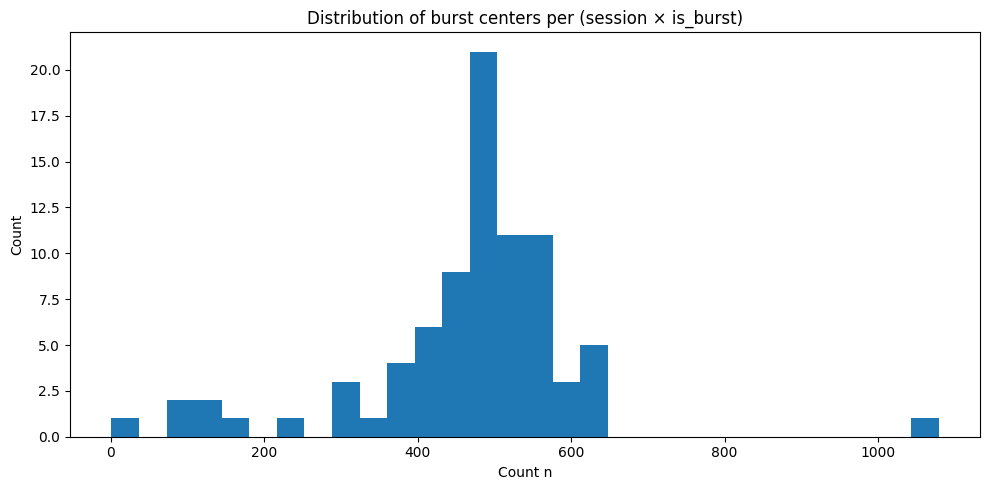

Empty DataFrame
Columns: [conference, session, n_bursts]
Index: []
[skip] Nothing to plot for: Distribution of TRUE bursts per session


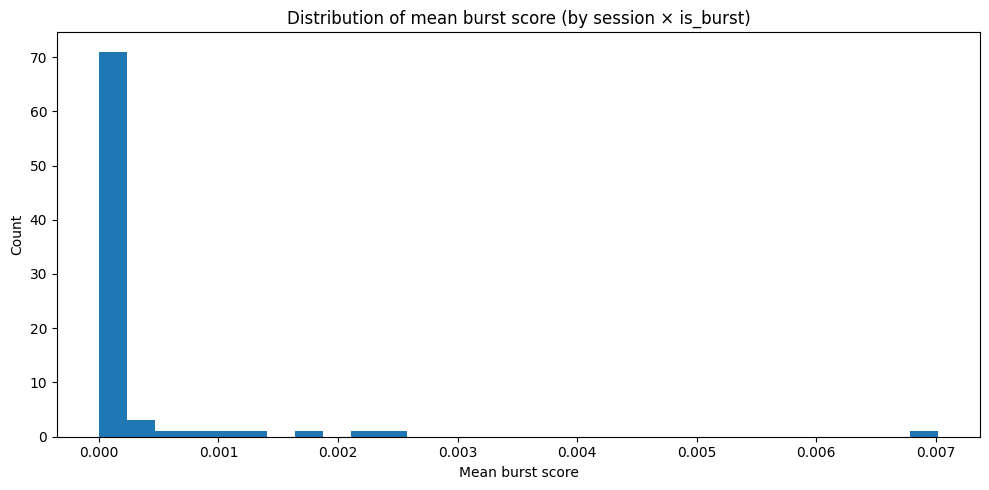

No TRUE bursts found to compute decision alignment.


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- Point to the correct directory (Data/scaling_outputs) ----
SCALING_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs")

burst_summary_path = SCALING_DIR / "burst_summary_by_session.csv"
burst_annot_path   = SCALING_DIR / "bursts_all_sessions_annot.csv"
burst_raw_path     = SCALING_DIR / "bursts_all_sessions_raw.csv"

# ---- Load ----
burst_summary = pd.read_csv(burst_summary_path)
burst_annot   = pd.read_csv(burst_annot_path)
burst_raw     = pd.read_csv(burst_raw_path)

print("Summary columns:", burst_summary.columns.tolist())
print("Annot columns:",   burst_annot.columns.tolist())
print("Raw columns:",     burst_raw.columns.tolist())

# ---------- Helpers ----------
def _safe_hist(series, title, xlabel, ylabel="Count", bins=30):
    series = pd.Series(series).dropna()
    if series.empty:
        print(f"[skip] Nothing to plot for: {title}")
        return
    plt.figure(figsize=(10,5))
    plt.hist(series, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

# 1) How many burst centers per (session × is_burst) group?
if "n" in burst_summary.columns:
    _safe_hist(burst_summary["n"], 
               "Distribution of burst centers per (session × is_burst)",
               "Count n")
else:
    print("[skip] 'n' not in burst_summary; available:", burst_summary.columns.tolist())

# 2) True bursts per session (reconstruct from raw)
needed_cols = {"conference","session","is_burst"}
if needed_cols.issubset(burst_raw.columns):
    bursts_only = burst_raw[burst_raw["is_burst"] == True]
    bursts_per_session = (bursts_only
                          .groupby(["conference","session"])
                          .size()
                          .reset_index(name="n_bursts"))
    print(bursts_per_session.sort_values("n_bursts", ascending=False).head(10))
    _safe_hist(bursts_per_session["n_bursts"],
               "Distribution of TRUE bursts per session",
               "Number of flagged bursts")
else:
    print(f"[skip] Missing columns in bursts_all_sessions_raw for #2; need {needed_cols}")

# 3) Mean burst score (from summary)
if "mean_burst" in burst_summary.columns:
    _safe_hist(burst_summary["mean_burst"],
               "Distribution of mean burst score (by session × is_burst)",
               "Mean burst score")
else:
    print("[skip] 'mean_burst' not in burst_summary; available:", burst_summary.columns.tolist())

# 4) Alignment with decision labels (from annotated file)
def has_decision(lbls):
    # nearest_labels may be a stringified list or NaN
    if isinstance(lbls, str):
        return "decision" in lbls.lower()
    if isinstance(lbls, (list, tuple)):
        return any("decision" in str(x).lower() for x in lbls)
    return False

needed_cols = {"conference","session","is_burst","nearest_labels"}
if needed_cols.issubset(burst_annot.columns):
    annot_true = burst_annot[burst_annot["is_burst"] == True].copy()
    if len(annot_true):
        annot_true["has_decision"] = annot_true["nearest_labels"].apply(has_decision)
        rate = float(annot_true["has_decision"].mean())
        print(f"Share of TRUE bursts with a nearby 'decision' label: {rate:.2%}")
    else:
        print("No TRUE bursts found to compute decision alignment.")
else:
    print(f"[skip] Missing columns in bursts_all_sessions_annot for #4; need {needed_cols}")


## Analyzing all the conferences

In [8]:
# === Re-run bursts with more permissive gates + diagnostics ===
from pathlib import Path
import numpy as np, pandas as pd
from tqdm import tqdm

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"
SENT_PATH   = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"
EMB_PATH    = SCALING_DIR / "embeddings_all.npy"

sent_all = pd.read_csv(SENT_PATH)
embeddings = np.load(EMB_PATH)

# Keep natural order so embeddings stay aligned
order_cols = [c for c in ["conference","session","_utter_row","_sent_idx"] if c in sent_all.columns]
if order_cols:
    sent_all = sent_all.sort_values(order_cols, ignore_index=True)

# ---- New parameters ----
WINDOW_HALF_SEC   = 60.0   # Δ
PAIR_MAX_GAP_SEC  = 45.0   # δ
SIM_THRESHOLD     = 0.68   # θ
BURST_THRESHOLD   = 0.08   # β
MIN_SPEAKERS      = 2      # m

def compute_bursts_for_session_diag(df: pd.DataFrame, E: np.ndarray,
                                    window_half, pair_gap, sim_thr, burst_thr, min_speakers):
    times    = df["sent_time_sec"].to_numpy(float)
    speakers = df["speaker"].astype(str).to_numpy()
    n = len(df)

    out = []
    L = 0
    for c in range(n):
        t0, t1 = times[c] - window_half, times[c] + window_half
        while L < n and times[L] < t0: L += 1
        R = c
        while R+1 < n and times[R+1] <= t1: R += 1
        if R - L + 1 < 2:
            out.append((times[c], 0.0, 0, 0, 0.0))
            continue

        idx = np.arange(L, R+1)
        T = times[idx]
        U = speakers[idx]
        M = E[idx] @ E[idx].T  # embeddings were normalized → cosine sims

        # mask: no self, |Δt| ≤ δ, cross-speaker
        m = np.ones_like(M, dtype=bool)
        np.fill_diagonal(m, False)
        dT = np.abs(T[:,None]-T[None,:])
        m &= (dT <= pair_gap)
        m &= (U[:,None] != U[None,:])

        iu = np.triu_indices(len(idx), 1)
        sel = m[iu]
        pair_count = int(sel.sum())
        if pair_count == 0:
            out.append((times[c], 0.0, 0, 0, 0.0))
            continue

        sims = M[iu][sel]
        hit  = sims >= sim_thr
        burst_score = float(hit.mean())

        # distinct speakers among hits
        hit_mat = np.zeros_like(M, dtype=bool)
        hit_mat[iu] = sel & (M[iu] >= sim_thr)
        hit_mat = np.triu(hit_mat, 1) | np.tril(hit_mat.T, 0)
        part_speakers = set()
        for a,b in zip(*np.where(hit_mat)):
            part_speakers.add(U[a]); part_speakers.add(U[b])
        num_part = len(part_speakers)

        is_burst = (burst_score >= burst_thr) & (num_part >= min_speakers)
        out.append((times[c], burst_score, num_part, pair_count, float(hit.sum())))

    res = pd.DataFrame(out, columns=["center_time_sec","burst_score","num_participants",
                                     "pair_count","hit_pairs"])
    res["is_burst"] = (res["burst_score"] >= burst_thr) & (res["num_participants"] >= min_speakers)
    return res

def recompute_all(sent_df, emb):
    outputs = []
    start = 0
    for (conf, sess), g in tqdm(sent_df.groupby(["conference","session"], sort=False), desc="Sessions"):
        n = len(g)
        subE = emb[start:start+n]
        b = compute_bursts_for_session_diag(
            g.reset_index(drop=True), subE,
            WINDOW_HALF_SEC, PAIR_MAX_GAP_SEC, SIM_THRESHOLD, BURST_THRESHOLD, MIN_SPEAKERS
        )
        b["conference"] = conf; b["session"] = sess
        outputs.append(b)
        start += n
    return pd.concat(outputs, ignore_index=True) if outputs else pd.DataFrame()

bursts_new = recompute_all(sent_all, embeddings)

# Save and print quick diagnostics
out_raw = SCALING_DIR / "bursts_all_sessions_raw_v2.csv"
bursts_new.to_csv(out_raw, index=False)
print("Wrote:", out_raw, "| rows:", len(bursts_new))

print("\nGate diagnostics (global):")
print(bursts_new[["pair_count","hit_pairs","num_participants","burst_score"]].describe().to_string())
print("True-burst rate:", bursts_new["is_burst"].mean())


Sessions: 100%|██████████| 82/82 [00:08<00:00, 10.01it/s]


Wrote: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/bursts_all_sessions_raw_v2.csv | rows: 38303

Gate diagnostics (global):
         pair_count     hit_pairs  num_participants   burst_score
count  38303.000000  38303.000000      38303.000000  38303.000000
mean      71.774691      0.103099          0.110592      0.000476
std      303.279875      0.638680          0.519716      0.005387
min        0.000000      0.000000          0.000000      0.000000
25%        0.000000      0.000000          0.000000      0.000000
50%        0.000000      0.000000          0.000000      0.000000
75%       24.000000      0.000000          0.000000      0.000000
max     4384.000000      9.000000          5.000000      0.333333
True-burst rate: 0.0005221523118293606


In [9]:
import pandas as pd

# --- Load your new recomputed file ---
path = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/bursts_all_sessions_raw_v2.csv"
df = pd.read_csv(path)

# --- Basic sanity checks ---
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Any TRUE bursts?:", df["is_burst"].any())
print("Count of TRUE bursts:", int(df["is_burst"].sum()))
print("True-burst rate (%):", 100 * df["is_burst"].mean())

# --- Show top of file to inspect values ---
print("\nHead of file:")
print(df.head(10))

# --- Session-level summary ---
if {"conference","session","is_burst"}.issubset(df.columns):
    bursts_per_session = (
        df[df["is_burst"]==True]
        .groupby(["conference","session"])
        .size()
        .reset_index(name="n_bursts")
    )
    print("\nSessions with the most bursts:")
    print(bursts_per_session.sort_values("n_bursts", ascending=False).head(10))


Shape: (38303, 8)
Columns: ['center_time_sec', 'burst_score', 'num_participants', 'pair_count', 'hit_pairs', 'is_burst', 'conference', 'session']
Any TRUE bursts?: True
Count of TRUE bursts: 20
True-burst rate (%): 0.05221523118293606

Head of file:
   center_time_sec  burst_score  num_participants  pair_count  hit_pairs  \
0       511.500000          0.0                 0           0        0.0   
1       272.070312          0.0                 0           0        0.0   
2       287.070312          0.0                 0           0        0.0   
3       152.409756          0.0                 0           0        0.0   
4       155.395122          0.0                 0           0        0.0   
5       162.485366          0.0                 0           0        0.0   
6       175.836585          0.0                 0           0        0.0   
7       184.502439          0.0                 0           0        0.0   
8       191.509756          0.0                 0           0     

We've pulled out **20 bursts** across all **83 sessions**

In [11]:
# === Rebuild annotated bursts for v2 thresholds ===
from pathlib import Path
import pandas as pd
import numpy as np
import re

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"

SENT_PATH   = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"
RAW_V2_PATH = SCALING_DIR / "bursts_all_sessions_raw_v2.csv"
ANNOT_V2_PATH = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"

# --- Load ---
sent_all = pd.read_csv(SENT_PATH)
raw_v2   = pd.read_csv(RAW_V2_PATH)

# Keep natural order (no time sort)
order_cols = [c for c in ["conference","session","_utter_row","_sent_idx"] if c in sent_all.columns]
if order_cols:
    sent_all = sent_all.sort_values(order_cols, ignore_index=True)

# --- Label normalizer from 'annotations' free text (loose match; tweak if needed) ---
def normalize_labels(x):
    if not isinstance(x, str) or not x.strip():
        return []
    tokens = [t.strip().lower() for t in re.split(r"[;,/|]", x) if t.strip()]
    return tokens

sent_all["labels_norm"] = sent_all.get("annotations", "").apply(normalize_labels)

# --- Annotate: nearest sentence to each center_time (per session) ---
def annotate_bursts(bursts_df, sentences_df):
    out_rows = []
    for (conf, sess), bgrp in bursts_df.groupby(["conference","session"], sort=False):
        sgrp = sentences_df[(sentences_df["conference"]==conf) & (sentences_df["session"]==sess)]
        if sgrp.empty:
            # carry rows with Nones if we somehow lack sentences
            for _, r in bgrp.iterrows():
                out_rows.append({**r,
                                 "nearest_sentence": None,
                                 "nearest_labels": None,
                                 "nearest_speaker": None,
                                 "nearest_time_sec": None})
            continue

        times = sgrp["sent_time_sec"].to_numpy(dtype=float)
        for _, r in bgrp.iterrows():
            ct = float(r["center_time_sec"])
            idx = int(np.argmin(np.abs(times - ct)))
            near = sgrp.iloc[idx]
            out_rows.append({
                **r,
                "nearest_sentence": near.get("sentence"),
                "nearest_labels": near.get("labels_norm"),
                "nearest_speaker": near.get("speaker"),
                "nearest_time_sec": float(near.get("sent_time_sec", np.nan)),
            })
    return pd.DataFrame(out_rows)

annot_v2 = annotate_bursts(raw_v2, sent_all)

# Save
annot_v2.to_csv(ANNOT_V2_PATH, index=False)
print("Wrote:", ANNOT_V2_PATH, "| rows:", len(annot_v2))

# Quick check: how many TRUE bursts now?
print("TRUE bursts in v2 annot:", int(annot_v2["is_burst"].sum()))

# Show a sample of TRUE bursts with context columns
sample_cols = ["conference","session","center_time_sec","burst_score","num_participants",
               "nearest_speaker","nearest_sentence","nearest_labels"]
print(annot_v2[annot_v2["is_burst"]==True][sample_cols].head(20).to_string(index=False))

# Optional: focus on the two sessions you saw in raw_v2
top_sessions = ["2021_10_01_MZT_S11","2021_06_10_SLU_S1"]
sub = annot_v2[(annot_v2["is_burst"]==True) & (annot_v2["session"].isin(top_sessions))]
if not sub.empty:
    print("\nTop sessions (v2) preview:")
    print(sub[sample_cols].head(20).to_string(index=False))
else:
    print("\n[Note] No TRUE bursts for the specified top sessions in the v2 annotated file (double-check session names).")


Wrote: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/bursts_all_sessions_annot_v2.csv | rows: 38303
TRUE bursts in v2 annot: 20
        conference            session  center_time_sec  burst_score  num_participants nearest_speaker                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                nearest_sentenc

Auto-picked session: 2021_10_01_MZT_S11 / 2021_10_01_MZT_S11
Saved timeline: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/viz/timeline_2021_10_01_MZT_S11_2021_10_01_MZT_S11.png


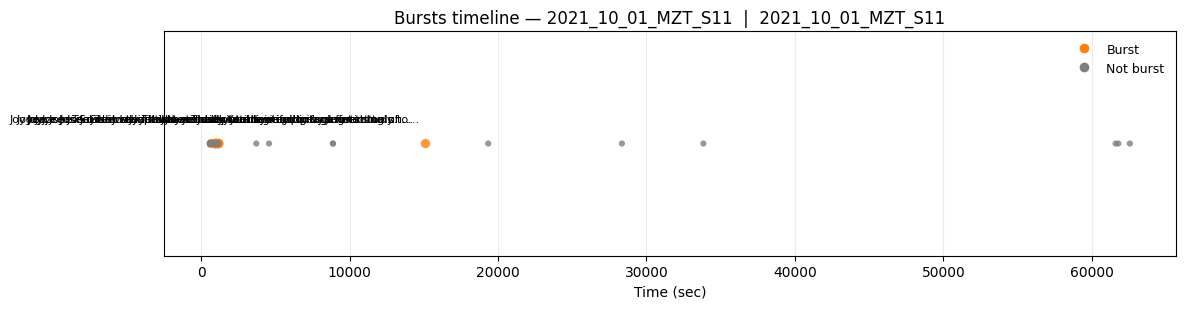

Saved reading pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/viz/reading_pack_2021_10_01_MZT_S11_2021_10_01_MZT_S11.csv


In [12]:
# ===================== Session timeline visualization (bursts) =====================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"

ANNOT_V2_PATH = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"
SENT_PATH     = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"
OUT_DIR       = SCALING_DIR / "viz"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- Load data ----------------
annot_v2 = pd.read_csv(ANNOT_V2_PATH)
sent_all = pd.read_csv(SENT_PATH)

# Keep natural order if available
order_cols = [c for c in ["conference","session","_utter_row","_sent_idx"] if c in sent_all.columns]
if order_cols:
    sent_all = sent_all.sort_values(order_cols, ignore_index=True)

# --------------- Helper: pick a session ---------------
def pick_bursty_session(annot_df: pd.DataFrame) -> tuple[str,str]:
    """Return (conference, session) with most TRUE bursts; if none, returns first pair."""
    if annot_df["is_burst"].any():
        top = (annot_df[annot_df["is_burst"]==True]
               .groupby(["conference","session"])
               .size()
               .reset_index(name="n_bursts")
               .sort_values("n_bursts", ascending=False))
        if len(top):
            return str(top.iloc[0]["conference"]), str(top.iloc[0]["session"])
    # fallback to most represented session
    fallback = (annot_df.groupby(["conference","session"])
                .size().reset_index(name="n")
                .sort_values("n", ascending=False))
    if len(fallback):
        return str(fallback.iloc[0]["conference"]), str(fallback.iloc[0]["session"])
    return None, None

# --------------- Visualization ---------------
def plot_session_bursts(annot_df: pd.DataFrame,
                        conf: str, sess: str,
                        label_top_k: int = 8,
                        label_wrap: int = 60,
                        figsize=(12, 3.2)):
    sub = annot_df[(annot_df["conference"]==conf) & (annot_df["session"]==sess)].copy()
    if sub.empty:
        print(f"[no data] {conf} / {sess}")
        return

    # scatter parameters
    x = sub["center_time_sec"].to_numpy(float)
    is_burst = sub["is_burst"].to_numpy(bool)
    scores = sub["burst_score"].to_numpy(float)
    parts = sub["num_participants"].to_numpy(int)

    # size by score (bounded)
    s = 20 + 180 * np.clip(scores, 0, 1)

    # color: non-burst gray, burst orange
    colors = np.where(is_burst, "tab:orange", "tab:gray")

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x, np.zeros_like(x), s=s, c=colors, alpha=0.8, edgecolors="none")
    ax.set_yticks([])
    ax.set_xlabel("Time (sec)")
    ax.set_title(f"Bursts timeline — {sess}  |  {conf}")

    # Highlight the top-K bursts (by score) with tiny labels
    top = sub.sort_values("burst_score", ascending=False).head(label_top_k)
    for _, r in top.iterrows():
        if not r["is_burst"]:
            continue
        t = float(r["center_time_sec"])
        lab_speaker = str(r.get("nearest_speaker", "") or "")
        lab_sent = str(r.get("nearest_sentence", "") or "")
        # short snippet
        snippet = textwrap.shorten(lab_sent, width=label_wrap, placeholder="…")
        lab = f"{lab_speaker}: {snippet}" if lab_speaker else snippet
        ax.annotate(lab, xy=(t, 0), xytext=(0, 14), textcoords="offset points",
                    rotation=0, ha="center", va="bottom", fontsize=8, color="black")

    # grid for readability
    ax.grid(axis="x", alpha=0.25)

    # legend proxy
    from matplotlib.lines import Line2D
    leg = [Line2D([0],[0], marker='o', color='w', label='Burst',
                  markerfacecolor='tab:orange', markersize=8),
           Line2D([0],[0], marker='o', color='w', label='Not burst',
                  markerfacecolor='tab:gray', markersize=8)]
    ax.legend(handles=leg, loc="upper right", frameon=False, fontsize=9)

    plt.tight_layout()
    # Save image
    out_png = OUT_DIR / f"timeline_{conf}_{sess}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print("Saved timeline:", out_png)
    plt.show()

# --------------- Reading pack (windows around top bursts) ---------------
def extract_reading_pack(conf: str, sess: str, top_k: int = 5, half_width_sec: float = 20.0) -> Path | None:
    bsub = annot_v2[(annot_v2["conference"]==conf) & (annot_v2["session"]==sess)]
    if bsub.empty:
        print(f"[no bursts] {conf}/{sess}")
        return None
    bsub = bsub.sort_values("burst_score", ascending=False).head(top_k)

    ssub = sent_all[(sent_all["conference"]==conf) & (sent_all["session"]==sess)]
    if ssub.empty:
        print(f"[no sentences] {conf}/{sess}")
        return None

    rows = []
    for _, r in bsub.iterrows():
        center = float(r["center_time_sec"])
        lo, hi = center - half_width_sec, center + half_width_sec
        window = ssub[(ssub["sent_time_sec"] >= lo) & (ssub["sent_time_sec"] <= hi)]
        window = window.sort_values("sent_time_sec", ignore_index=True)
        if window.empty:
            continue
        dfw = window[["sent_time_sec","speaker","sentence"]].copy()
        dfw.insert(0, "center_time_sec", center)
        dfw.insert(0, "session", sess)
        dfw.insert(0, "conference", conf)
        rows.append(dfw)

    if not rows:
        print(f"[no windows] {conf}/{sess}")
        return None

    pack = pd.concat(rows, ignore_index=True)
    out_csv = OUT_DIR / f"reading_pack_{conf}_{sess}.csv"
    pack.to_csv(out_csv, index=False)
    print("Saved reading pack:", out_csv)
    return out_csv

# --------------- Run for a session ---------------
# AUTO: pick most bursty session if you don't want to hardcode
conf_auto, sess_auto = pick_bursty_session(annot_v2)
print("Auto-picked session:", conf_auto, "/", sess_auto)

# OR set manually, e.g.:
# conf_auto, sess_auto = "2021_10_01_MZT_S11", "2021_10_01_MZT_S11"
# conf_auto, sess_auto = "2021_06_10_SLU_S1", "2021_06_10_SLU_S1"

if conf_auto and sess_auto:
    plot_session_bursts(annot_v2, conf_auto, sess_auto, label_top_k=8, label_wrap=60)
    extract_reading_pack(conf_auto, sess_auto, top_k=5, half_width_sec=20.0)
else:
    print("[no session available to plot]")


In [13]:
import pandas as pd

# Paths (adjust if needed)
annot_path = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/bursts_all_sessions_annot_v2.csv"
utterance_path = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/utterance_data_aligned_full.csv"

# Load data
annot = pd.read_csv(annot_path)
utter = pd.read_csv(utterance_path)

# Just TRUE bursts
bursts = annot[annot["is_burst"] == True].copy()

print("Total flagged bursts:", len(bursts))

# Function to extract transcript context around a burst
def extract_context(burst_row, window=45):
    conf = burst_row["conference"]
    sess = burst_row["session"]
    t = burst_row["center_time_sec"]

    # Match utterances in same session within ±window
    session_utts = utter[utter["session"] == sess]
    context = session_utts[
        (session_utts["start_sec_adjusted"] <= t + window) &
        (session_utts["end_sec_adjusted"]   >= t - window)
    ].copy()

    context["burst_center"] = t
    context["burst_session"] = sess
    return context

# Collect contexts for first N bursts
N = 5
contexts = []
for i, row in bursts.head(N).iterrows():
    ctx = extract_context(row, window=45)
    contexts.append(ctx)

contexts_df = pd.concat(contexts, ignore_index=True)

# Save for reading
out_path = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/burst_context_samples.csv"
contexts_df.to_csv(out_path, index=False)

print(f"Saved context for {N} bursts to {out_path}")
print(contexts_df[["burst_session","burst_center","speaker","transcript"]].head(20))


Total flagged bursts: 20
Saved context for 5 bursts to /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/burst_context_samples.csv
        burst_session  burst_center          speaker  \
0   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
1   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
2   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
3   2021_06_10_SLU_S1    731.236364  Stilianos Louca   
4   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
5   2021_06_10_SLU_S1    731.236364   Noah Planavsky   
6   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
7   2021_06_10_SLU_S1    731.236364   Noah Planavsky   
8   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
9   2021_06_10_SLU_S1    731.236364   Noah Planavsky   
10  2021_06_10_SLU_S1    731.236364   Noah Planavsky   
11  2021_06_10_SLU_S1    731.236364     Morgan Raven   
12  2021_06_10_SLU_S1    731.236364      Smadar Naoz   
13  2021_06_10_SLU_S1    731.236364  Solange Duhamel   
14  2021_06_1

### burst meta + transcript context

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"

# Inputs
ANNOT_V2  = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"   # rebuilt annotated file
SENT_ALL  = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"   # sentence-level table

# Output dir
PACK_DIR  = SCALING_DIR / "reading_packs"
PACK_DIR.mkdir(parents=True, exist_ok=True)

# Controls
TOP_K_GLOBAL   = None   # e.g., 50 to take top 50 bursts globally; None = take all True bursts
MAX_PER_SESSION = 5     # cap per-session packs; set to None for no cap
HALF_WIDTH_SEC  = 20.0  # ± seconds of transcript around each burst
MAX_ROWS_WINDOW = 120   # safety cap on rows per window

# Load
annot = pd.read_csv(ANNOT_V2)
sents = pd.read_csv(SENT_ALL)

# Sentence text column: prefer 'sentence', else 'transcript'
SENT_TEXT_COL = "sentence" if "sentence" in sents.columns else ("transcript" if "transcript" in sents.columns else None)
if SENT_TEXT_COL is None:
    raise ValueError("No sentence text column found. Expected 'sentence' or 'transcript' in sentences_ALL_filled.csv")

# Natural order (if present)
order_cols = [c for c in ["conference","session","_utter_row","_sent_idx"] if c in sents.columns]
if order_cols:
    sents = sents.sort_values(order_cols, ignore_index=True)

# Keep TRUE bursts and add stable id
bursts = annot[annot["is_burst"]==True].copy()
if bursts.empty:
    print("[No TRUE bursts in annot v2. Re-run thresholds or check paths.]")
else:
    bursts = bursts.sort_values(["conference","session","center_time_sec"]).reset_index(drop=True)
    bursts["burst_id"] = np.arange(1, len(bursts)+1)

    # Choose which bursts to pack
    if TOP_K_GLOBAL is not None:
        choose = bursts.sort_values("burst_score", ascending=False).head(int(TOP_K_GLOBAL))
    else:
        # Optionally cap per session
        if MAX_PER_SESSION is not None:
            choose = (bursts.sort_values(["conference","session","burst_score"], ascending=[True,True,False])
                      .groupby(["conference","session"], as_index=False)
                      .head(int(MAX_PER_SESSION)))
        else:
            choose = bursts

    def make_pack_rows(b, half_width=HALF_WIDTH_SEC, max_rows=MAX_ROWS_WINDOW):
        conf, sess = str(b["conference"]), str(b["session"])
        ct   = float(b["center_time_sec"])
        meta = {
            "burst_id":          int(b["burst_id"]),
            "conference":        conf,
            "session":           sess,
            "center_time_sec":   ct,
            "burst_score":       float(b.get("burst_score", np.nan)),
            "num_participants":  int(b.get("num_participants", 0)),
            "nearest_speaker":   b.get("nearest_speaker", ""),
            "nearest_sentence":  b.get("nearest_sentence", ""),
            "nearest_time_sec":  float(b.get("nearest_time_sec", np.nan)) if pd.notna(b.get("nearest_time_sec", np.nan)) else np.nan,
        }
        sub = sents[(sents["conference"]==conf) & (sents["session"]==sess)].copy()
        if sub.empty:
            return pd.DataFrame([{**meta, "rel_sec": np.nan, "sent_time_sec": np.nan,
                                  "speaker":"", SENT_TEXT_COL:"", "is_nearest": False}])

        window = sub[(sub["sent_time_sec"] >= ct - half_width) & (sub["sent_time_sec"] <= ct + half_width)].copy()
        window = window.sort_values("sent_time_sec", ignore_index=True)
        if window.empty:
            return pd.DataFrame([{**meta, "rel_sec": np.nan, "sent_time_sec": np.nan,
                                  "speaker":"", SENT_TEXT_COL:"", "is_nearest": False}])

        window["rel_sec"] = window["sent_time_sec"] - ct

        # mark the nearest line
        if not np.isnan(meta["nearest_time_sec"]):
            window["is_nearest"] = np.isclose(window["sent_time_sec"], meta["nearest_time_sec"], atol=1e-6)
        else:
            idx = int(np.argmin(np.abs(window["sent_time_sec"] - ct)))
            window["is_nearest"] = False
            window.loc[idx, "is_nearest"] = True

        # keep columns (include is_nearest!)
        cols_keep = ["sent_time_sec","rel_sec","speaker", SENT_TEXT_COL, "is_nearest"]
        # include any code columns if present
        for c in ["annotations","dialogue_act","decision","explanation","new_idea"]:
            if c in window.columns: cols_keep.append(c)
        window = window[cols_keep].head(max_rows)

        # prepend meta columns so each row carries the burst summary
        for k in list(meta.keys())[::-1]:
            window.insert(0, k, meta[k])
        return window

    # Build packs
    packs = []
    for _, b in choose.iterrows():
        rows = make_pack_rows(b)
        packs.append(rows)
        out = PACK_DIR / f"pack_{b['conference']}_{b['session']}_burst{int(b['burst_id']):03d}.csv"
        rows.to_csv(out, index=False)

    if packs:
        pack_all = pd.concat(packs, ignore_index=True)
        out_all = PACK_DIR / ("pack_TOPK_bursts.csv" if TOP_K_GLOBAL else "pack_ALL_bursts_capped.csv")
        pack_all.to_csv(out_all, index=False)
        print(f"Wrote {len(choose)} bursts to per-burst files in:", PACK_DIR)
        print("Also wrote combined pack:", out_all)

        # SAFE preview (only print columns that exist)
        want = ["burst_id","conference","session","center_time_sec",
                "burst_score","num_participants","sent_time_sec","rel_sec",
                "speaker", SENT_TEXT_COL, "is_nearest"]
        preview_cols = [c for c in want if c in pack_all.columns]
        print(pack_all[preview_cols].head(20).to_string(index=False))
    else:
        print("[No packs created]")


Wrote 10 bursts to per-burst files in: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/reading_packs
Also wrote combined pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/reading_packs/pack_ALL_bursts_capped.csv
 burst_id        conference           session  center_time_sec  burst_score  num_participants  sent_time_sec    rel_sec              speaker                                                                                                                                                                                                                                                                                                                                                     sentence  is_nearest
        3 2021_06_10_SLU_S1 2021_06_10_SLU_S1       731.236364     0.333333                 2     713.845794 -17.390569          Smadar Naoz                                                                          

### CHECKING IT

In [16]:
import pandas as pd
from pathlib import Path

SCALING_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs")
PACK_ALL    = SCALING_DIR / "reading_packs" / "pack_ALL_bursts_capped.csv"

pack = pd.read_csv(PACK_ALL)
print("Rows:", len(pack))
print("Columns:", pack.columns.tolist())

# Peek a few rows per burst_id
cols = [c for c in [
    "burst_id","conference","session","center_time_sec","burst_score","num_participants",
    "sent_time_sec","rel_sec","speaker","sentence","is_nearest",
    "annotations","dialogue_act","decision","explanation","new_idea"
] if c in pack.columns]
display(pack[cols].head(20))


Rows: 303
Columns: ['burst_id', 'conference', 'session', 'center_time_sec', 'burst_score', 'num_participants', 'nearest_speaker', 'nearest_sentence', 'nearest_time_sec', 'sent_time_sec', 'rel_sec', 'speaker', 'sentence', 'is_nearest', 'annotations', 'dialogue_act']


,burst_id,conference,session,center_time_sec,burst_score,num_participants,sent_time_sec,rel_sec,speaker,sentence,is_nearest,annotations,dialogue_act
0,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,713.845794,-17.390569,Smadar Naoz,"about temperature, I wonder if we if we're als...",False,[{'present new idea': 'The speaker introduces ...,NaN
1,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,714.400894,-16.835470,Niki Parenteau,"Um, so it's it is a possibility to look for that.",False,[{'expand on existing idea': 'The speaker buil...,NaN
2,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,716.465278,-14.771086,Jeffrey Marlow,"Number two, um, are perhaps uh, over focus on ...",False,[{'summarize discussion': {'explanation': 'Jef...,NaN
3,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,716.503565,-14.732798,Jay Forsythe(he/him),"Um, the for example like Murchison one of the ...",False,[{'explain or define term or concept': 'Jay ex...,NaN
4,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,718.878788,-12.357576,Niki Parenteau,"And um, as Richard said, we'll kind of keep it...",False,{'assign task': 'Niki assigns Jeff the task of...,NaN
5,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,720.546304,-10.690060,Niki Parenteau,"Um, but again, it might be difficult uh to put...",False,[{'expand on existing idea': 'The speaker buil...,NaN
6,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,720.623572,-10.612791,Smadar Naoz,So we can have um tidal effects that will cont...,False,[{'present new idea': 'The speaker introduces ...,NaN
7,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,720.667870,-10.568494,Noah Planavsky,You have actual empirical records of it and th...,False,"{'expand on existing idea': ""Noah expands on R...",NaN
8,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,720.994186,-10.242178,Solange Duhamel,"So I think thinking of both the microbes, thei...",False,[{'explain or define term or concept': 'The sp...,NaN
9,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,724.244318,-6.992045,Jeffrey Marlow,"Um, this idea of meteorites as net positive or...",False,[{'summarize discussion': {'explanation': 'Jef...,NaN


Note: right now it is focusing on 2 people bursts, but this can be scaled so then we can (for e.g.) find optimal no. of people for convergence.

## running it now for 2-7 participants

Recomputing participants per burst in ±20.0s windows...
Participant thresholds to evaluate: [2, 3, 4, 5, 6, 7]
[m≥2] eligible windows=17 | sentences IN=238 OUT=38065
[m≥3] eligible windows=17 | sentences IN=238 OUT=38065
[m≥4] eligible windows=17 | sentences IN=238 OUT=38065
[m≥5] eligible windows=16 | sentences IN=233 OUT=38070
[m≥6] eligible windows=12 | sentences IN=174 OUT=38129
[m≥7] eligible windows=8 | sentences IN=124 OUT=38179
Wrote: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/label_enrichment_ann_and_regex_by_participants_RECOMP.csv
Wrote (filtered): /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/label_enrichment_ann_and_regex_FILTERED_RECOMP.csv

=== Top signals for m≥2 (filtered; MIN_IN=10, MIN_OUT=10) ===
                  token kind  hit_out  hit_in  rate_out_per_1000  rate_in_per_1000  ratio_in_out
            assign task  ann     1650      21             43.347            88.235

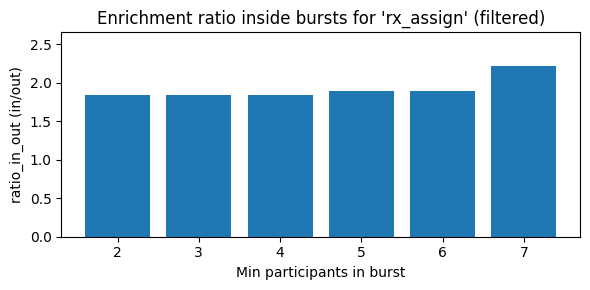

Saved plot: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/enrichment_rx_assign_filtered.png


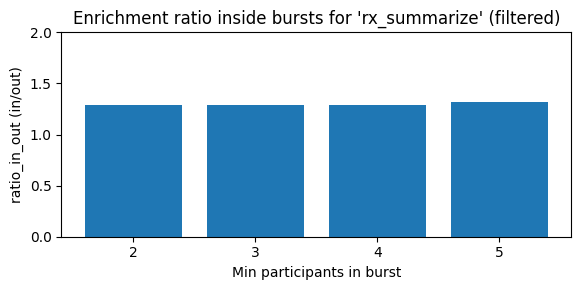

Saved plot: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/enrichment_rx_summarize_filtered.png


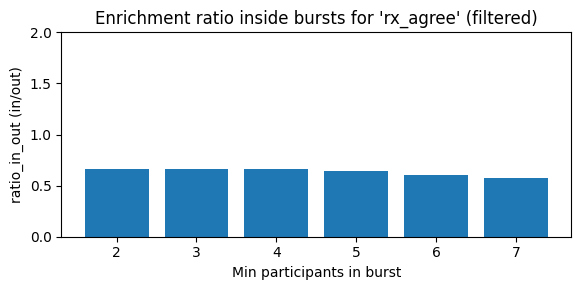

Saved plot: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/enrichment_rx_agree_filtered.png


In [23]:
# ========= ENRICHMENT v3 (robust): recompute participants; ann-tokens + regex-tags; counts & filters =========
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# ---- Paths ----
DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"
ANNOT_V2    = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"   # TRUE bursts (any m)
SENTS_ALL   = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"

OUT_DIR     = SCALING_DIR / "summaries"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Load ----
annot = pd.read_csv(ANNOT_V2)
sents = pd.read_csv(SENTS_ALL)

# Prefer 'sentence' text; fallback to 'transcript'
TEXT_COL = "sentence" if "sentence" in sents.columns else ("transcript" if "transcript" in sents.columns else None)
if TEXT_COL is None:
    raise ValueError("Expected a text column named 'sentence' or 'transcript' in sentences_ALL_filled.csv")

# ========== 1) TOKENIZATION ==========
# (A) Codebook-style tokens from 'annotations' (substring match; tweak KEYS if needed)
KEYS = [
    "decision", "assign task", "action item",
    "agreement", "agree", "consensus",
    "summarize discussion",
    "present new idea", "new idea",
    "expand on existing idea",
    "explain or define", "explain", "define",
    "encourage", "question"
]
def extract_tokens(x: str) -> list[str]:
    if not isinstance(x, str): return []
    low = x.lower()
    return [k for k in KEYS if k in low]

sents["ann_tokens"] = sents.get("annotations","").apply(extract_tokens)

# (B) Regex tags (from BOTH annotations + sentence text) — safer quoting with VERBOSE
LEX = {
    "rx_decision": re.compile(r"""
        \b(?:                                   
            decid(?:e|ing|ed|es)                 # decide, deciding, decided, decides
          | we(?:['’]|\s)ll\s(?:go|do|use)       # we'll go/do/use (allow space)
          | let(?:['’]|\s)s\s(?:go|do|use)       # let's go/do/use (allow space)
          | agree\s(?:to|on)                      # agree to/on
          | choose|chose|picked                   # choose/chose/picked
          | settle\s(?:on|for)                    # settle on/for
          | we\s(?:are|(?:['’]re)|re)\s(?:settling|going)  # we are/’re/re settling/going
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_assign": re.compile(r"""
        \b(?:
            assign|assignment|owner|ownership
          | you(?:['’]|\s)ll\s(?:do|own|take)     # you'll do/own/take
          | i(?:['’]|\s)ll\s(?:do|own|take)       # i'll do/own/take
          | can\s+you\s+\w+                        # can you <verb>
          | action\s+item
          | follow[-\s]?up
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_summarize": re.compile(r"""
        \b(?:
            sum(?:mary|marize|marising|marizing)   # summary/summarize/...
          | recap
          | in\s+summary
          | to\s+sum\s+up
          | what\s+we\s+(?:have|got)
          | so\s+(?:the|we)
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_agree": re.compile(r"""
        \b(?:
            agree|agreement
          | sounds\s+good
          | sgtm
          | works\s+for\s+me
          | that\s+works
          | yes|yep|ok(?:ay)?
        )\b
    """, re.IGNORECASE | re.VERBOSE),
}

def tag_via_regex(row) -> dict:
    text = f"{str(row.get('annotations',''))} || {str(row.get(TEXT_COL,''))}"
    return {name: bool(rx.search(text)) for name, rx in LEX.items()}

# quick sanity: ensure patterns behave
_ = tag_via_regex({"annotations":"", TEXT_COL:"let’s go with option A"})  # should hit rx_decision
_ = tag_via_regex({"annotations":"you'll take notes", TEXT_COL:""})       # should hit rx_assign
_ = tag_via_regex({"annotations":"", TEXT_COL:"to sum up, we propose..."})# should hit rx_summarize
_ = tag_via_regex({"annotations":"", TEXT_COL:"sounds good to me"})       # should hit rx_agree

rx_df = sents.apply(tag_via_regex, axis=1, result_type="expand")
sents = pd.concat([sents, rx_df], axis=1)

# ========== 2) HELPERS ==========
session_index = {k: df for k, df in sents.groupby(["conference","session"])}

def participants_in_window(conf: str, sess: str, center_t: float, W: float) -> int:
    key = (conf, sess)
    if key not in session_index: return 0
    S = session_index[key]
    m = (S["sent_time_sec"] >= center_t - W) & (S["sent_time_sec"] <= center_t + W)
    if not m.any(): return 0
    return int(S.loc[m, "speaker"].dropna().astype(str).str.strip().nunique())

def mark_sentences_in_windows(bursts_df: pd.DataFrame, W: float) -> pd.Series:
    """Boolean Series over sents.index: True if sentence inside ANY burst window."""
    mark = pd.Series(False, index=sents.index)
    for (conf, sess), grp in bursts_df.groupby(["conference","session"]):
        if (conf, sess) not in session_index: continue
        S = session_index[(conf, sess)]
        for ct in grp["center_time_sec"].astype(float):
            m = (S["sent_time_sec"] >= ct - W) & (S["sent_time_sec"] <= ct + W)
            if m.any():
                mark.loc[S.index[m]] = True
    return mark

def enrich_counts_for_mask(in_mask: pd.Series) -> pd.DataFrame:
    """
    Compute counts/rates for:
      - ann_tokens (explode)
      - regex tags (rx_* boolean columns)
    Returns tall table with columns:
      token, kind (ann/rx), hit_in, hit_out, base_in, base_out, rate_in_per_1000, rate_out_per_1000, ratio_in_out
    """
    base_in  = int(in_mask.sum())
    base_out = int((~in_mask).sum())

    rows = []

    # (A) ann_tokens
    ann = sents[["ann_tokens"]].copy()
    ann["in_burst"] = in_mask.values
    ann_exp = ann.explode("ann_tokens").dropna(subset=["ann_tokens"])
    if not ann_exp.empty:
        c_in  = ann_exp[ann_exp["in_burst"]==True ]["ann_tokens"].value_counts()
        c_out = ann_exp[ann_exp["in_burst"]==False]["ann_tokens"].value_counts()
        tokens = set(c_in.index) | set(c_out.index)
        for tok in tokens:
            hit_in  = int(c_in.get(tok, 0))
            hit_out = int(c_out.get(tok, 0))
            rate_in  = (hit_in  / max(base_in, 1))  * 1000.0
            rate_out = (hit_out / max(base_out, 1)) * 1000.0
            ratio    = (rate_in + 1e-9) / (rate_out + 1e-9)
            rows.append({"token": tok, "kind": "ann",
                         "hit_in": hit_in, "hit_out": hit_out,
                         "base_in": base_in, "base_out": base_out,
                         "rate_in_per_1000": rate_in, "rate_out_per_1000": rate_out,
                         "ratio_in_out": ratio})

    # (B) regex tags
    rx_cols = [c for c in sents.columns if c.startswith("rx_")]
    rx = sents[rx_cols].copy()
    rx["in_burst"] = in_mask.values
    for col in rx_cols:
        hit_in  = int(rx.loc[rx["in_burst"]==True,  col].sum())
        hit_out = int(rx.loc[rx["in_burst"]==False, col].sum())
        rate_in  = (hit_in  / max(base_in, 1))  * 1000.0
        rate_out = (hit_out / max(base_out, 1)) * 1000.0
        ratio    = (rate_in + 1e-9) / (rate_out + 1e-9)
        rows.append({"token": col, "kind": "rx",
                     "hit_in": hit_in, "hit_out": hit_out,
                     "base_in": base_in, "base_out": base_out,
                     "rate_in_per_1000": rate_in, "rate_out_per_1000": rate_out,
                     "ratio_in_out": ratio})

    return pd.DataFrame(rows)

# ========== 3) RECOMPUTE PARTICIPANTS & RUN ENRICHMENT ==========
W = 20.0  # half-width seconds for both participant count & membership
bursts_true = annot[annot["is_burst"]==True][["conference","session","center_time_sec"]].copy()
if bursts_true.empty:
    raise ValueError("No TRUE bursts in annot_v2. Regenerate bursts first.")

print(f"Recomputing participants per burst in ±{W}s windows...")
bursts_true["participants_in_window"] = [
    participants_in_window(str(r.conference), str(r.session), float(r.center_time_sec), W)
    for _, r in bursts_true.iterrows()
]

max_m = int(min(max([2] + bursts_true["participants_in_window"].tolist()), 7))
thresholds = list(range(2, max_m+1))
print("Participant thresholds to evaluate:", thresholds)

all_tables = []
for m in thresholds:
    eligible_bursts = bursts_true[bursts_true["participants_in_window"] >= m]
    n_eligible = len(eligible_bursts)
    in_mask = mark_sentences_in_windows(eligible_bursts, W)
    in_ct, out_ct = int(in_mask.sum()), int((~in_mask).sum())
    print(f"[m≥{m}] eligible windows={n_eligible} | sentences IN={in_ct} OUT={out_ct}")

    tbl = enrich_counts_for_mask(in_mask)
    if tbl.empty:
        continue
    tbl["min_participants"] = m
    all_tables.append(tbl)

combined = pd.concat(all_tables, ignore_index=True) if all_tables else pd.DataFrame()

# Save raw combined
raw_out = OUT_DIR / "label_enrichment_ann_and_regex_by_participants_RECOMP.csv"
combined.to_csv(raw_out, index=False)
print("Wrote:", raw_out)

# ========== 4) OPTIONAL: FILTER OUT TINY-COUNT ARTIFACTS ==========
MIN_IN  = 10  # require at least this many hits inside bursts (corpus-wide) to trust a token
MIN_OUT = 10  # and outside bursts
filtered = combined[(combined["hit_in"] >= MIN_IN) & (combined["hit_out"] >= MIN_OUT)].copy()

filt_out = OUT_DIR / "label_enrichment_ann_and_regex_FILTERED_RECOMP.csv"
filtered.to_csv(filt_out, index=False)
print("Wrote (filtered):", filt_out)

# ========== 5) PRINT HEADLINES ==========
def show_top(df, m, topn=12, kinds=("ann","rx")):
    sub = df[(df["min_participants"]==m) & (df["kind"].isin(kinds))].copy()
    if sub.empty:
        print(f"[m≥{m}] (no rows after filter)")
        return
    sub = sub.sort_values("ratio_in_out", ascending=False)
    cols = ["token","kind","hit_out","hit_in","rate_out_per_1000","rate_in_per_1000","ratio_in_out"]
    print(f"\n=== Top signals for m≥{m} (filtered; MIN_IN={MIN_IN}, MIN_OUT={MIN_OUT}) ===")
    print(sub[cols].head(topn).round(3).to_string(index=False))

if not filtered.empty:
    for m in thresholds:
        show_top(filtered, m)
else:
    print("[Note] After filtering by MIN_IN/MIN_OUT, no rows remained. Lower thresholds or inspect raw_out CSV.]")

# ========== 6) WIDE TABLES FOR WRITE-UP (focus set) ==========
FOCUS = ["decision", "assign task", "summarize discussion", "present new idea", "agreement",
         "rx_decision", "rx_assign", "rx_summarize", "rx_agree"]

def wide_focus(df):
    sub = df[df["token"].isin(FOCUS)].copy()
    if sub.empty:
        return pd.DataFrame()
    wide = (sub.pivot_table(index="token", columns="min_participants",
                            values="ratio_in_out", aggfunc="mean")
              .reindex(columns=[m for m in thresholds if m in sub["min_participants"].unique()])
           )
    return wide

wide_raw = wide_focus(combined)
wide_filt = wide_focus(filtered)

if not wide_raw.empty:
    p_raw = OUT_DIR / "enrichment_ratios_wide_focus_RAW_RECOMP.csv"
    wide_raw.to_csv(p_raw)
    print("Saved wide focus (raw):", p_raw)
    print("\n=== Focus ratios by participants (RAW) ===")
    print(wide_raw.round(2).to_string())

if not wide_filt.empty:
    p_filt = OUT_DIR / "enrichment_ratios_wide_focus_FILTERED_RECOMP.csv"
    wide_filt.to_csv(p_filt)
    print("Saved wide focus (filtered):", p_filt)
    print("\n=== Focus ratios by participants (FILTERED) ===")
    print(wide_filt.round(2).to_string())

# ========== 7) (Optional) small plots for regex signals ==========
if not wide_filt.empty:
    for tok in ["rx_decision","rx_assign","rx_summarize","rx_agree"]:
        if tok not in wide_filt.index:
            continue
        series = wide_filt.loc[tok].dropna()
        if series.empty:
            continue
        plt.figure(figsize=(6,3))
        plt.bar(series.index.astype(str), series.values)
        plt.title(f"Enrichment ratio inside bursts for '{tok}' (filtered)")
        plt.xlabel("Min participants in burst")
        plt.ylabel("ratio_in_out (in/out)")
        plt.ylim(0, max(2.0, float(series.values.max())*1.2))
        plt.tight_layout()
        png = OUT_DIR / f"enrichment_{tok}_filtered.png"
        plt.savefig(png, dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved plot:", png)

## Data Driven Lexicon Expansion (Like-phrases inside bursts)

In [25]:
# ===== ONE-BLOCK: mine decision cues -> extend regex -> recompute enrichment (m = 2..7) =====
from pathlib import Path
import pandas as pd
import numpy as np
import re
from collections import Counter

# ---------------- Paths ----------------
DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"
SENTS_ALL   = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"
ANNOT_V2    = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"
OUT_DIR     = SCALING_DIR / "summaries"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- Load ----------------
sents = pd.read_csv(SENTS_ALL)
annot = pd.read_csv(ANNOT_V2)
TEXT_COL = "sentence" if "sentence" in sents.columns else ("transcript" if "transcript" in sents.columns else None)
if TEXT_COL is None:
    raise ValueError("Expected a text column named 'sentence' or 'transcript' in sentences_ALL_filled.csv")

# ---------------- Session helpers ----------------
session_index = {k: df for k, df in sents.groupby(["conference","session"])}

def mark_sentences_in_windows(bursts_df: pd.DataFrame, W: float = 20.0) -> pd.Series:
    """Boolean Series over sents.index: True if sentence in ANY ±W window around a burst center."""
    mark = pd.Series(False, index=sents.index)
    for (conf, sess), grp in bursts_df.groupby(["conference","session"]):
        if (conf, sess) not in session_index:
            continue
        S = session_index[(conf, sess)]
        for ct in grp["center_time_sec"].astype(float):
            m = S["sent_time_sec"].between(ct - W, ct + W)
            if m.any():
                mark.loc[S.index[m]] = True
    return mark

def participants_in_window(conf: str, sess: str, center_t: float, W: float = 20.0) -> int:
    if (conf, sess) not in session_index:
        return 0
    S = session_index[(conf, sess)]
    m = S["sent_time_sec"].between(center_t - W, center_t + W)
    return int(S.loc[m, "speaker"].dropna().astype(str).str.strip().nunique())

# ---------------- Build bursts with recomputed participation ----------------
W = 20.0
bursts_true = annot[annot["is_burst"]==True][["conference","session","center_time_sec"]].copy()
if bursts_true.empty:
    raise ValueError("No TRUE bursts found in annot_v2. Generate bursts first.")
bursts_true["participants_in_window"] = [
    participants_in_window(str(r.conference), str(r.session), float(r.center_time_sec), W)
    for _, r in bursts_true.iterrows()
]

# ---------------- (1) AUTO-MINE N-GRAMS inside stronger bursts (m≥5 by default) ----------------
m_cut = 5
eligible = bursts_true[bursts_true["participants_in_window"] >= m_cut]
in_mask  = mark_sentences_in_windows(eligible, W=W)

IN  = sents.loc[in_mask,  TEXT_COL].dropna().astype(str)
OUT = sents.loc[~in_mask, TEXT_COL].dropna().astype(str)

def norm(t: str) -> str:
    t = t.lower()
    t = re.sub(r"[^a-z0-9\s’']", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

IN  = IN.map(norm)
OUT = OUT.map(norm)

def ngrams(tokens, n):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def collect_ngrams(series, n):
    c = Counter()
    for line in series:
        toks = line.split()
        c.update(ngrams(toks, n))
    return c

c2_in,  c2_out  = collect_ngrams(IN, 2),  collect_ngrams(OUT, 2)
c3_in,  c3_out  = collect_ngrams(IN, 3),  collect_ngrams(OUT, 3)

def top_enriched(c_in, c_out, base_in, base_out, min_in=8, min_out=8, topk=50):
    rows = []
    for ngram, v_in in c_in.items():
        v_out = c_out.get(ngram, 0)
        if v_in < min_in or v_out < min_out:
            continue
        rate_in  = (v_in  / base_in)  * 1000.0
        rate_out = (v_out / base_out) * 1000.0
        ratio    = (rate_in + 1e-9) / (rate_out + 1e-9)
        rows.append((ngram, v_in, v_out, rate_in, rate_out, ratio))
    rows.sort(key=lambda x: x[-1], reverse=True)
    return rows[:topk]

base_in, base_out = len(IN), len(OUT)
cand2 = top_enriched(c2_in, c2_out, base_in, base_out, min_in=8,  min_out=8,  topk=50)
cand3 = top_enriched(c3_in, c3_out, base_in, base_out, min_in=6,  min_out=6,  topk=50)

print(f"[auto-mine] m≥{m_cut}, W={W}s | IN={base_in} OUT={base_out}")
def quick_show(rows, label):
    print(f"\nTop enriched {label}:")
    for ngram, v_in, v_out, ri, ro, rr in rows[:20]:
        print(f"{ngram:30s} in={v_in:3d} out={v_out:4d}  rate_in={ri:6.2f}  rate_out={ro:6.2f}  ratio={rr:6.2f}")
quick_show(cand2, "bigrams")
quick_show(cand3, "trigrams")

# ---------------- (2) TARGETED CONCORDANCE for decision-like cues (inspect a few) ----------------
CUES = [
    r"\bwe(?:['’]|\s)ll\s(?:go|do|use|proceed|choose|pick|stick)\b",
    r"\blet(?:['’]|\s)s\s(?:go|do|use|proceed|move|pick)\b",
    r"\bwe\s(?:are|(?:['’]re)|re)\s(?:going|settling|choosing|picking)\b",
    r"\bwe\sdecided\b", r"\bwe\sagree(?:\s+to|\s+on)?\b",
    r"\bthe\s+plan\s+is\s+to\b", r"\bwe\splan\s+to\b",
    r"\bgo\s+ahead\s+and\s+\w+\b", r"\bwe\s(?:will|shall)\s+\w+\b",
    r"\bwe\s+should\s+\w+\b", r"\bwe\s+need\s+to\s+\w+\b",
    r"\bwe['’]re\s+going\s+to\s+\w+\b", r"\bwe\s+choose\b", r"\bwe\s+pick\b"
]
CUE_RX = re.compile("|".join(CUES), re.IGNORECASE)

cand_in = sents.loc[in_mask, ["conference","session","speaker","sent_time_sec",TEXT_COL]].dropna(subset=[TEXT_COL]).copy()
cand_in["decision_like"] = cand_in[TEXT_COL].str.contains(CUE_RX, regex=True)
hits = cand_in[cand_in["decision_like"]].copy()
print(f"\n[concordance] decision-like matches inside bursts (m≥{m_cut}): {len(hits)}")
if len(hits):
    print(hits.sample(min(12, len(hits)), random_state=7)[["conference","session","speaker","sent_time_sec",TEXT_COL]].to_string(index=False))

# ---------------- (3) BUILD supplemental rx_decision from curated + mined phrases ----------------
def pick_decisiony(rows, limit=15):
    keep = []
    for ngram, v_in, v_out, ri, ro, rr in rows:
        # only keep phrases that contain decision-ish tokens
        if any(tok in ngram for tok in ["we", "let", "go", "plan", "decid", "choose", "pick", "agree", "proceed", "stick"]):
            keep.append(re.escape(ngram))
    return keep[:limit]

MUST_HAVE = [
    r"we(?:['’]|\s)ll\s(?:proceed|stick|aim|adopt|finalize)",
    r"let(?:['’]|\s)s\s(?:proceed|stick|finalize|lock\s+in)",
    r"\bthe\s+plan\s+is\s+to\b",
    r"\bwe\splan\s+to\b",
    r"\bgo\s+ahead\s+and\s+\w+\b",
    r"\bwe\s(?:will|shall)\s+\w+\b",
    r"\bwe\s(?:agree|agreed)(?:\s+to|\s+on)?\b",
    r"\bwe\sdecided\b",
    r"\bwe(?:['’]|\s)re\s+going\s+to\s+\w+\b",
]

auto_keep = pick_decisiony(cand2, 15) + pick_decisiony(cand3, 15)
supp_union = r"(?:%s)" % "|".join(MUST_HAVE + auto_keep) if (MUST_HAVE or auto_keep) else r"(?!x)x"
RX_DECISION_SUPP = re.compile(supp_union, re.IGNORECASE)

# ---------------- (4) TAG regex columns (assign/summarize/agree + decision base OR supplemental) ----------------
LEX = {
    "rx_decision_base": re.compile(r"""
        \b(?:                                   
            decid(?:e|ing|ed|es)                 # decide, decided, ...
          | we(?:['’]|\s)ll\s(?:go|do|use)       # we'll go/do/use
          | let(?:['’]|\s)s\s(?:go|do|use)       # let's go/do/use
          | agree\s(?:to|on)                      # agree to/on
          | choose|chose|picked                   # choose/chose/picked
          | settle\s(?:on|for)                    # settle on/for
          | we\s(?:are|(?:['’]re)|re)\s(?:settling|going)  # we're settling/going
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_assign": re.compile(r"""
        \b(?:
            assign|assignment|owner|ownership
          | you(?:['’]|\s)ll\s(?:do|own|take)
          | i(?:['’]|\s)ll\s(?:do|own|take)
          | can\s+you\s+\w+
          | action\s+item
          | follow[-\s]?up
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_summarize": re.compile(r"""
        \b(?:
            sum(?:mary|marize|marising|marizing)
          | recap
          | in\s+summary
          | to\s+sum\s+up
          | what\s+we\s+(?:have|got)
          | so\s+(?:the|we)
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_agree": re.compile(r"""
        \b(?:
            agree|agreement
          | sounds\s+good
          | sgtm
          | works\s+for\s+me
          | that\s+works
          | yes|yep|ok(?:ay)?
        )\b
    """, re.IGNORECASE | re.VERBOSE),
}

def tag_row(row):
    text = f"{str(row.get('annotations',''))} || {str(row.get(TEXT_COL,''))}"
    rx = {
        "rx_assign":    bool(LEX["rx_assign"].search(text)),
        "rx_summarize": bool(LEX["rx_summarize"].search(text)),
        "rx_agree":     bool(LEX["rx_agree"].search(text)),
    }
    rx["rx_decision"] = bool(LEX["rx_decision_base"].search(text)) or bool(RX_DECISION_SUPP.search(text))
    return rx

rx_df = sents.apply(tag_row, axis=1, result_type="expand")
for c in ["rx_decision","rx_assign","rx_summarize","rx_agree"]:
    sents[c] = rx_df[c]

# ---------------- (5) Build annotation tokens from the 'annotations' JSON-ish text ----------------
KEYS = [
    "decision", "assign task", "action item",
    "agreement", "agree", "consensus",
    "summarize discussion",
    "present new idea", "new idea",
    "expand on existing idea",
    "explain or define", "explain", "define",
    "encourage", "question"
]
def extract_tokens(x):
    if not isinstance(x, str): return []
    low = x.lower()
    return [k for k in KEYS if k in low]
sents["ann_tokens"] = sents.get("annotations","").apply(extract_tokens)

# ---------------- (6) Enrichment computation ----------------
def enrich_counts_for_mask(in_mask: pd.Series) -> pd.DataFrame:
    """Return tall table of ann + regex signals with hit counts and in/out rates."""
    base_in  = int(in_mask.sum())
    base_out = int((~in_mask).sum())
    rows = []

    # (A) ann_tokens
    ann = sents[["ann_tokens"]].copy()
    ann["in_burst"] = in_mask.values
    ann_exp = ann.explode("ann_tokens").dropna(subset=["ann_tokens"])
    if not ann_exp.empty:
        c_in  = ann_exp[ann_exp["in_burst"]==True ]["ann_tokens"].value_counts()
        c_out = ann_exp[ann_exp["in_burst"]==False]["ann_tokens"].value_counts()
        tokens = set(c_in.index) | set(c_out.index)
        for tok in tokens:
            hit_in  = int(c_in.get(tok, 0))
            hit_out = int(c_out.get(tok, 0))
            rate_in  = (hit_in  / max(base_in, 1))  * 1000.0
            rate_out = (hit_out / max(base_out, 1)) * 1000.0
            ratio    = (rate_in + 1e-9) / (rate_out + 1e-9)
            rows.append({"token": tok, "kind": "ann",
                         "hit_in": hit_in, "hit_out": hit_out,
                         "base_in": base_in, "base_out": base_out,
                         "rate_in_per_1000": rate_in, "rate_out_per_1000": rate_out,
                         "ratio_in_out": ratio})

    # (B) regex tags
    rx_cols = ["rx_decision","rx_assign","rx_summarize","rx_agree"]
    rx = sents[rx_cols].copy()
    rx["in_burst"] = in_mask.values
    for col in rx_cols:
        hit_in  = int(rx.loc[rx["in_burst"]==True,  col].sum())
        hit_out = int(rx.loc[rx["in_burst"]==False, col].sum())
        rate_in  = (hit_in  / max(base_in, 1))  * 1000.0
        rate_out = (hit_out / max(base_out, 1)) * 1000.0
        ratio    = (rate_in + 1e-9) / (rate_out + 1e-9)
        rows.append({"token": col, "kind": "rx",
                     "hit_in": hit_in, "hit_out": hit_out,
                     "base_in": base_in, "base_out": base_out,
                     "rate_in_per_1000": rate_in, "rate_out_per_1000": rate_out,
                     "ratio_in_out": ratio})
    return pd.DataFrame(rows)

# thresholds m = 2..min(7, observed max)
max_m = int(min(max([2] + bursts_true["participants_in_window"].tolist()), 7))
thresholds = list(range(2, max_m+1))
print("\nParticipant thresholds to evaluate:", thresholds)

all_tables = []
for m in thresholds:
    eligible_bursts = bursts_true[bursts_true["participants_in_window"] >= m]
    n_eligible = len(eligible_bursts)
    in_mask = mark_sentences_in_windows(eligible_bursts, W=W)
    in_ct, out_ct = int(in_mask.sum()), int((~in_mask).sum())
    print(f"[m≥{m}] eligible windows={n_eligible} | sentences IN={in_ct} OUT={out_ct}")

    tbl = enrich_counts_for_mask(in_mask)
    if tbl.empty:
        continue
    tbl["min_participants"] = m
    all_tables.append(tbl)

combined = pd.concat(all_tables, ignore_index=True) if all_tables else pd.DataFrame()
raw_out = OUT_DIR / "label_enrichment_ann+regex_SUPP_RECOMP.csv"
combined.to_csv(raw_out, index=False)
print("\nWrote RAW enrichment:", raw_out)

# filter tiny-count artifacts
MIN_IN, MIN_OUT = 10, 10
filtered = combined[(combined["hit_in"] >= MIN_IN) & (combined["hit_out"] >= MIN_OUT)].copy()
filt_out = OUT_DIR / "label_enrichment_ann+regex_SUPP_RECOMP_FILTERED.csv"
filtered.to_csv(filt_out, index=False)
print("Wrote FILTERED enrichment:", filt_out)

# quick headlines
def show_top(df, m, topn=12, kinds=("ann","rx")):
    sub = df[(df["min_participants"]==m) & (df["kind"].isin(kinds))].copy()
    if sub.empty:
        print(f"[m≥{m}] (no rows after filter)")
        return
    sub = sub.sort_values("ratio_in_out", ascending=False)
    cols = ["token","kind","hit_out","hit_in","rate_out_per_1000","rate_in_per_1000","ratio_in_out"]
    print(f"\n=== Top signals for m≥{m} (filtered; MIN_IN={MIN_IN}, MIN_OUT={MIN_OUT}) ===")
    print(sub[cols].head(topn).round(3).to_string(index=False))

if not filtered.empty:
    for m in thresholds:
        show_top(filtered, m)

# wide focus tables for write-up
FOCUS = ["decision", "assign task", "summarize discussion", "present new idea", "agreement",
         "rx_decision", "rx_assign", "rx_summarize", "rx_agree"]

def wide_focus(df):
    sub = df[df["token"].isin(FOCUS)].copy()
    if sub.empty:
        return pd.DataFrame()
    wide = (sub.pivot_table(index="token", columns="min_participants",
                            values="ratio_in_out", aggfunc="mean")
              .reindex(columns=[m for m in thresholds if m in sub["min_participants"].unique()]))
    return wide

wide_raw = wide_focus(combined)
wide_filt = wide_focus(filtered)

if not wide_raw.empty:
    p_raw = OUT_DIR / "enrichment_ratios_wide_focus_SUPP_RAW.csv"
    wide_raw.to_csv(p_raw)
    print("\nSaved wide focus (RAW):", p_raw)
    print(wide_raw.round(2).to_string())

if not wide_filt.empty:
    p_filt = OUT_DIR / "enrichment_ratios_wide_focus_SUPP_FILTERED.csv"
    wide_filt.to_csv(p_filt)
    print("\nSaved wide focus (FILTERED):", p_filt)
    print(wide_filt.round(2).to_string())

[auto-mine] m≥5, W=20.0s | IN=233 OUT=38017

Top enriched bigrams:
the host                       in= 16 out= 207  rate_in= 68.67  rate_out=  5.44  ratio= 12.61
how much                       in=  8 out= 124  rate_in= 34.33  rate_out=  3.26  ratio= 10.53
like that                      in= 13 out= 336  rate_in= 55.79  rate_out=  8.84  ratio=  6.31
and how                        in=  8 out= 344  rate_in= 34.33  rate_out=  9.05  ratio=  3.79
it is                          in=  9 out= 394  rate_in= 38.63  rate_out= 10.36  ratio=  3.73
there are                      in=  9 out= 584  rate_in= 38.63  rate_out= 15.36  ratio=  2.51
if we                          in=  8 out= 555  rate_in= 34.33  rate_out= 14.60  ratio=  2.35
lot of                         in= 11 out= 954  rate_in= 47.21  rate_out= 25.09  ratio=  1.88
would be                       in=  9 out= 821  rate_in= 38.63  rate_out= 21.60  ratio=  1.79
a lot                          in= 13 out=1238  rate_in= 55.79  rate_out= 32.56  ratio=

### composite decision flag + clean mining

In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

# --------- CONFIG ---------
W     = 20.0   # half-window size in seconds around the hit
m_cut = 5      # minimum distinct speakers in the burst window (group moment)
OUT_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries")

# --------- ASSUMES you already have these in memory ---------
# sents: sentences_ALL_filled.csv loaded as DataFrame
# bursts_true: DataFrame with columns ['conference','session','center_time_sec','participants_in_window']
# mark_sentences_in_windows(): function that returns a boolean mask over sents for a set of bursts

# --------- 1) Ensure rx_* flags exist (or create as False) ---------
for col in ["rx_decision", "rx_assign", "rx_summarize"]:
    if col not in sents.columns:
        sents[col] = False

# --------- 2) Create a looser decision signal: decision_any ---------
# Uses rx_decision/assign/summarize OR text match "decision" in annotations.
if "decision_any" not in sents.columns:
    sents["decision_any"] = (
        sents["rx_decision"].astype(bool) |
        sents["rx_assign"].astype(bool) |
        sents["rx_summarize"].astype(bool) |
        sents.get("annotations", "").astype(str).str.contains(r"\bdecision\b", case=False, na=False)
    )

print("Counts of True flags:")
for col in ["rx_decision","rx_assign","rx_summarize","decision_any"]:
    if col in sents.columns:
        print(f"  {col:16s} -> {int(sents[col].sum())}")

# --------- 3) Rebuild session index AFTER new columns ---------
session_index = {(c, s): df.copy()
                 for (c, s), df in sents.groupby(["conference","session"], dropna=False)}

# --------- 4) Helper: pack a ±W-second context around a center time ---------
def pack_context(df_session: pd.DataFrame, center_t: float, half: float = 20.0) -> pd.DataFrame:
    m = df_session["sent_time_sec"].between(center_t - half, center_t + half)
    subset = df_session.loc[m].copy()

    # Prefer 'sentence' else 'transcript'
    text_col = "sentence" if "sentence" in subset.columns else ("transcript" if "transcript" in subset.columns else None)
    if text_col is None:
        subset["sentence"] = ""
        text_col = "sentence"

    base_cols = ["speaker", "sent_time_sec", text_col, "annotations"]
    sig_cols  = ["rx_decision", "rx_assign", "rx_summarize", "decision_any"]

    # ensure signals exist
    for col in sig_cols:
        if col not in subset.columns:
            subset[col] = False

    keep = [c for c in base_cols + sig_cols if c in subset.columns]
    out = subset[keep].copy()
    out["rel_sec"] = out["sent_time_sec"] - center_t
    out = out.rename(columns={text_col: "sentence"})
    return out.sort_values("sent_time_sec")

# --------- 5) Sentences inside windows for m_cut ---------
eligible = bursts_true[bursts_true["participants_in_window"] >= m_cut]
inside_mask = mark_sentences_in_windows(eligible, W=W)

print(f"\n[m≥{m_cut}] eligible windows: {len(eligible)}")
print(f"[m≥{m_cut}] sentences inside windows: {int(inside_mask.sum())}")

# --------- 6) Find decision_any hits INSIDE those windows ---------
hits = sents.loc[inside_mask & sents["decision_any"]].copy()
print(f"[m≥{m_cut}] decision_any hits inside windows: {len(hits)}")

# --------- 7) Build & save context packs ---------
OUT_DIR.mkdir(parents=True, exist_ok=True)
packs = []
for (conf, sess), grp in hits.groupby(["conference","session"], dropna=False):
    S = session_index.get((conf, sess))
    if S is None or S.empty:
        continue
    for ct in grp["sent_time_sec"].astype(float):
        ctx = pack_context(S, ct, half=W)
        ctx.insert(0, "center_time_sec", ct)
        ctx.insert(0, "session", sess)
        ctx.insert(0, "conference", conf)
        packs.append(ctx)

if packs:
    pack_all = pd.concat(packs, ignore_index=True)
    out_csv = OUT_DIR / f"decision_any_concordance_m{m_cut}.csv"
    pack_all.to_csv(out_csv, index=False)
    print("Wrote concordance pack:", out_csv)
    # small peek
    peek_cols = [c for c in ["conference","session","center_time_sec","speaker","sent_time_sec","rel_sec",
                             "sentence","rx_decision","rx_assign","rx_summarize","decision_any","annotations"]
                 if c in pack_all.columns]
    print(pack_all[peek_cols].head(12).to_string(index=False))
else:
    print(f"[Note] No decision_any hits inside m≥{m_cut} windows. Try lowering m_cut, increasing W, or enriching the regex cues.]")

Counts of True flags:
  rx_decision      -> 0
  rx_assign        -> 0
  rx_summarize     -> 0
  decision_any     -> 3682

[m≥5] eligible windows: 16
[m≥5] sentences inside windows: 233
[m≥5] decision_any hits inside windows: 14
Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m5.csv
       conference           session  center_time_sec         speaker  sent_time_sec    rel_sec                                                                                                                                                                                                                                                              sentence  rx_decision  rx_assign  rx_summarize  decision_any                                                                                                                                                                                                                        

In [32]:
from pathlib import Path
import pandas as pd

out_dir = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries")
out_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []

# Loop through m=2...7
for m_cut in range(2, 8):
    print(f"\n=== Running concordance for m≥{m_cut} ===")

    inside_mask = in_windows_for_m(m_cut, W=20.0)
    hits = sents.loc[inside_mask & sents["decision_any"]].copy()

    packs = []
    for (conf, sess), grp in hits.groupby(["conference","session"], dropna=False):
        S = session_index.get((conf, sess))
        if S is None or S.empty:
            continue
        for ct in grp["sent_time_sec"].astype(float):
            ctx = pack_context(S, ct, half=20.0)
            ctx.insert(0, "center_time_sec", ct)
            ctx.insert(0, "session", sess)
            ctx.insert(0, "conference", conf)
            packs.append(ctx)

    if packs:
        pack_all = pd.concat(packs, ignore_index=True)
        out_csv = out_dir / f"decision_any_concordance_m{m_cut}.csv"
        pack_all.to_csv(out_csv, index=False)
        print(f"[m≥{m_cut}] Wrote concordance pack:", out_csv)
        hit_count = len(pack_all)
    else:
        print(f"[m≥{m_cut}] No packs created")
        hit_count = 0

    # record stats for summary
    summary_rows.append({
        "m_cut": m_cut,
        "eligible_windows": int((bursts_true["participants_in_window"] >= m_cut).sum()),
        "sentences_in_windows": int(sents.loc[inside_mask].shape[0]),
        "decision_hits_in_windows": int(hits.shape[0]),
        "concordance_rows_written": hit_count
    })

# Save summary table
summary_df = pd.DataFrame(summary_rows)
summary_csv = out_dir / "decision_any_concordance_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("\n=== Summary of all m thresholds ===")
print(summary_df.to_string(index=False))


=== Running concordance for m≥2 ===
[m≥2] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m2.csv

=== Running concordance for m≥3 ===
[m≥3] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m3.csv

=== Running concordance for m≥4 ===
[m≥4] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m4.csv

=== Running concordance for m≥5 ===
[m≥5] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m5.csv

=== Running concordance for m≥6 ===
[m≥6] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m6.csv

=== Running concordance for m≥7 ===
[m≥7] Wr

this is in the right direction... ready for next step (below)

## the next three steps 

### building the QC samping (manual validation)

In [33]:
# === QC PACK: sample bursts for manual validation ===========================
from pathlib import Path
import pandas as pd
import numpy as np

# ---- paths (edit if different) ----
DATA_DIR     = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR  = DATA_DIR / "scaling_outputs"
SCALED_DIR   = DATA_DIR / "scaled"
SUMM_DIR     = SCALING_DIR / "summaries"
SUMM_DIR.mkdir(parents=True, exist_ok=True)

# choose which m to validate (you can loop this later)
m_cut   = 5
W       = 20.0       # ± seconds around burst center
N_TOTAL = 30         # total bursts to sample (stratified across sessions)

# input files produced earlier
CONCORD_PATH = SUMM_DIR / f"decision_any_concordance_m{m_cut}.csv"
SENTS_PATH   = SCALED_DIR / "sentences_ALL_filled.csv"

# ---- load ----
concord = pd.read_csv(CONCORD_PATH)
sents   = pd.read_csv(SENTS_PATH)

# Pick the best text column name
TEXT_COL = "sentence" if "sentence" in sents.columns else ("transcript" if "transcript" in sents.columns else None)
if TEXT_COL is None:
    raise ValueError("Expected 'sentence' or 'transcript' column in sentences_ALL_filled.csv")

# ensure expected cols in concord (robust rename if needed)
expected_cols = ["conference","session","center_time_sec","speaker","sent_time_sec","rel_sec",TEXT_COL]
for c in expected_cols:
    if c not in concord.columns:
        raise ValueError(f"Expected column '{c}' not found in {CONCORD_PATH.name}")

# one row per *burst* key
concord["burst_key"] = list(zip(concord["conference"].astype(str),
                                concord["session"].astype(str),
                                concord["center_time_sec"].astype(float)))

bursts = concord[["conference","session","center_time_sec","burst_key"]].drop_duplicates().copy()

# ---- stratified sampling across sessions ----
# compute how many to take per session (proportional, with at least 1 if possible)
counts = bursts["session"].value_counts()
weights = counts / counts.sum()
take_by_session = (weights * N_TOTAL).round().astype(int)

# ensure total == N_TOTAL by adjusting largest remainders
diff = N_TOTAL - int(take_by_session.sum())
if diff != 0:
    # add/subtract from sessions with highest counts
    adjust_order = counts.index.tolist()
    i = 0
    while diff != 0 and i < len(adjust_order):
        sess = adjust_order[i]
        new_val = take_by_session.get(sess, 0) + (1 if diff > 0 else -1)
        if new_val >= 0:
            take_by_session.loc[sess] = new_val
            diff += (-1 if diff > 0 else +1)
        i += 1

# now sample
sampled_keys = []
for sess, k in bursts.groupby("session"):
    k = k.sample(n=min(int(take_by_session.get(sess, 0)), len(k)), random_state=42) if take_by_session.get(sess, 0) > 0 else k.iloc[0:0]
    sampled_keys.extend(k["burst_key"].tolist())

sampled_keys = list(dict.fromkeys(sampled_keys))  # unique, keep order

# fallbacks if too few sampled (e.g., small corpus)
if len(sampled_keys) < min(N_TOTAL, len(bursts)):
    need = min(N_TOTAL, len(bursts)) - len(sampled_keys)
    remaining = [bk for bk in bursts["burst_key"].tolist() if bk not in sampled_keys]
    extra = remaining[:need]
    sampled_keys.extend(extra)

# clamp to size N_TOTAL if too many
if len(sampled_keys) > N_TOTAL:
    sampled_keys = sampled_keys[:N_TOTAL]

# ---- build the two artifacts ------------------------------------------------
# A) qc_bursts_list.csv : one row per selected burst (with teaser context) + annotation fields
rows = []
for (conf, sess, ct) in sampled_keys:
    # grab this burst window from concord (already has context rows)
    ctx = concord[(concord["conference"]==conf) &
                  (concord["session"]==sess) &
                  (concord["center_time_sec"]==ct)].copy()

    # teaser: 5 lines before, center line, 5 lines after (by rel_sec)
    ctx = ctx.sort_values("rel_sec")
    teaser = []
    for _, r in ctx.iterrows():
        teaser.append(f"[{r['rel_sec']:>+6.1f}s] {str(r['speaker'])}: {str(r[TEXT_COL])}")
    teaser_txt = "\n".join(teaser[:11])  # cap to 11 lines

    rows.append({
        "conference": conf,
        "session": sess,
        "center_time_sec": ct,
        "teaser_context": teaser_txt,

        # --- empty columns for YOU to fill in by hand ---
        "human_is_decision": "",          # 'Y' or 'N'
        "human_decision_type": "",        # e.g., 'assignment', 'choice', 'plan', 'consensus', 'summary', 'other'
        "human_initiator": "",            # free text (speaker name) or 'multiple'
        "human_notes": "",
        "human_confidence_1to5": ""       # 1 (low) ... 5 (high)
    })

qc_bursts = pd.DataFrame(rows)

# B) qc_burst_context.csv : full context for all sampled bursts (every line in window)
ctx_rows = []
for (conf, sess, ct) in sampled_keys:
    ctx = concord[(concord["conference"]==conf) &
                  (concord["session"]==sess) &
                  (concord["center_time_sec"]==ct)].copy()
    ctx = ctx.sort_values("rel_sec")
    for _, r in ctx.iterrows():
        ctx_rows.append({
            "conference": conf,
            "session": sess,
            "center_time_sec": ct,
            "rel_sec": r["rel_sec"],
            "sent_time_sec": r["sent_time_sec"],
            "speaker": r["speaker"],
            "text": r[TEXT_COL]
        })

qc_context = pd.DataFrame(ctx_rows)

# ---- save both ----
list_path    = SUMM_DIR / f"QC_bursts_list_m{m_cut}.csv"
context_path = SUMM_DIR / f"QC_burst_context_m{m_cut}.csv"
qc_bursts.to_csv(list_path, index=False)
qc_context.to_csv(context_path, index=False)

print("Wrote:")
print(" -", list_path)
print(" -", context_path)

# ---- (optional) write a tiny instructions file next to it ----
instructions = f"""QC instructions (m≥{m_cut}, W=±{W}s)

• Open QC_bursts_list_m{m_cut}.csv in Google Sheets or Excel.
• For each row (one burst), skim the teaser_context.
• If unclear, look up the full window in QC_burst_context_m{m_cut}.csv 
  (filter by the same conference, session, center_time_sec).
• Then fill:
  - human_is_decision: Y or N (does this window contain a real decision moment?)
  - human_decision_type: assignment / choice / plan / consensus / summary / other
  - human_initiator: who kicked off the decision (speaker name or 'multiple')
  - human_confidence_1to5: 1 (low) .. 5 (high)
  - human_notes: any nuance you'd like to capture
• Save your edits to a NEW file: QC_bursts_list_m{m_cut}_ANNOTATED.csv
"""
(INST_PATH := SUMM_DIR / f"QC_README_m{m_cut}.txt").write_text(instructions)
print("Wrote:", INST_PATH)

Wrote:
 - /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/QC_bursts_list_m5.csv
 - /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/QC_burst_context_m5.csv
Wrote: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/QC_README_m5.txt


## compute precision & quick diagnostics

In [ ]:
# === EVALUATE QC: load your annotations and score precision =================
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SUMM_DIR    = DATA_DIR / "scaling_outputs" / "summaries"

m_cut = 5  # must match the pack you annotated

# your edited file name here (same folder). If you used another name, update.
ANNOTATED_PATH = SUMM_DIR / f"QC_bursts_list_m{m_cut}_ANNOTATED.csv"

df = pd.read_csv(ANNOTATED_PATH)

# normalize human flags
def norm_y(val):
    if isinstance(val, str) and val.strip().lower() in {"y","yes","true","t","1"}:
        return 1
    if isinstance(val, (int,float)) and int(val)==1:
        return 1
    return 0

df["is_decision_human"] = df["human_is_decision"].apply(norm_y).astype(int)

# precision of the detector (we sampled from decision_any bursts)
precision = df["is_decision_human"].mean() if len(df) else np.nan

# decision type distribution among positives
type_counts = (df.loc[df["is_decision_human"]==1, "human_decision_type"]
                 .fillna("unknown").str.strip().str.lower().value_counts())

# initiators
initiators = (df.loc[df["is_decision_human"]==1, "human_initiator"]
                .fillna("").str.strip().replace("", "unspecified").value_counts())

# confidence stats
conf = pd.to_numeric(df.get("human_confidence_1to5", pd.Series([np.nan]*len(df))), errors="coerce")
conf_stats = conf.describe()

print(f"QC size: {len(df)}")
print(f"Estimated precision (human Y rate): {precision:.2%}" if pd.notna(precision) else "Precision: n/a")

print("\nDecision types (among human positives):")
print(type_counts.to_string())

print("\nInitiators (among human positives):")
print(initiators.head(15).to_string())

print("\nConfidence summary:")
print(conf_stats.to_string())

# --- OPTIONAL: session coverage and per-session precision ---
if {"conference","session","is_decision_human"}.issubset(df.columns):
    per_sess = (df.groupby(["conference","session"])
                  .agg(n=("is_decision_human","size"),
                       pos=("is_decision_human","sum"))
                  .assign(precision=lambda x: x["pos"]/x["n"]))
    print("\nPer-session precision (where sampled):")
    print(per_sess.sort_values("precision", ascending=False).head(10).round(3).to_string())

# --- OPTIONAL: export a compact report CSV you can paste in the doc ---
report = {
    "precision_overall": [precision],
    "n_sampled": [len(df)],
    "n_human_positive": [int(df["is_decision_human"].sum())],
    "confidence_mean": [conf.mean()],
    "confidence_median": [conf.median()]
}
rep = pd.DataFrame(report)
out_report = SUMM_DIR / f"QC_report_m{m_cut}.csv"
rep.to_csv(out_report, index=False)
print("\nWrote:", out_report)

## straight to the auto-summaries of each burst

In [35]:
# === Keyword-based (no-regex) decision mining + concordance packs for m=2..7 ===
from pathlib import Path
import pandas as pd
import numpy as np

# ---------------- Paths ----------------
DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"
SENTS_ALL   = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"
ANNOT_V2    = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"
OUT_DIR     = SCALING_DIR / "summaries"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- Load ----------------
sents = pd.read_csv(SENTS_ALL)
annot = pd.read_csv(ANNOT_V2)

# Which text column to read
TEXT_COL = "sentence" if "sentence" in sents.columns else ("transcript" if "transcript" in sents.columns else None)
if TEXT_COL is None:
    raise ValueError("Need a 'sentence' or 'transcript' column in sentences_ALL_filled.csv")

# We'll also use annotations text if present
ANN_COL = "annotations" if "annotations" in sents.columns else None

# ---------------- Helpers (no-regex matching) ----------------
def norm_text(x) -> str:
    # lower and collapse spaces; keep apostrophes
    t = str(x).lower()
    t = " ".join(t.split())
    return t

def contains_any(text: str, phrases: list[str]) -> bool:
    # literal substring search (no regex)
    if not text:
        return False
    return any(p in text for p in phrases)

# Build a single normalized text field (annotations + sentence)
if ANN_COL:
    sents["_norm_text"] = (sents[ANN_COL].fillna("").astype(str) + " || " + sents[TEXT_COL].fillna("").astype(str)).map(norm_text)
else:
    sents["_norm_text"] = sents[TEXT_COL].fillna("").astype(str).map(norm_text)

# ---------------- Keyword lexicon (literal substrings) ----------------
# Tweak/extend freely; these are deliberately broad, plain-English phrases
KW = {
    "decision": [
        "we will ", "we'll ", "let's ", "we should ", "we are going to", "we're going to",
        "we go with", "we chose", "we choose", "we decided", "we decide", "we'll go", "we'll do",
        "we'll use", "let us ", "we plan to", "we're planning to", "we are planning to",
        "settle on", "settle for", "we'll take", "we take that", "we'll pick", "we pick"
    ],
    "assign": [
        "can you ", "could you ", "please ", "you will ", "you'll ", "i will ", "i'll ",
        "action item", "follow up", "next steps", "i can take", "you can take",
        "i'll take", "you'll take", "assign ", "take the lead", "own this"
    ],
    "summarize": [
        "in summary", "to sum up", "recap", "the takeaway", "so we ", "so the ",
        "what we have", "overall", "in short", "to summarize"
    ],
    "agree": [
        "i agree", "we agree", "agreed", "sounds good", "sgtm", "works for me",
        "that works", "yes ", "yep", "ok ", "okay ", "sure "
    ]
}

# Guarantee trailing spaces for some tokens above; also include versions without trailing spaces
def expand_kw(list_in):
    out = set(list_in)
    for p in list_in:
        if p.endswith(" "):  # add trimmed variant too
            out.add(p.strip())
    return sorted(out)

for k in KW:
    KW[k] = expand_kw([norm_text(p) for p in KW[k]])

# ---------------- Build boolean flags from keywords ----------------
sents["kw_decision"]  = sents["_norm_text"].apply(lambda t: contains_any(t, KW["decision"]))
sents["kw_assign"]    = sents["_norm_text"].apply(lambda t: contains_any(t, KW["assign"]))
sents["kw_summarize"] = sents["_norm_text"].apply(lambda t: contains_any(t, KW["summarize"]))
sents["kw_agree"]     = sents["_norm_text"].apply(lambda t: contains_any(t, KW["agree"]))

# Composite “decision-ish” flag (you can tweak this recipe)
sents["decision_any"] = (
    sents["kw_decision"] | sents["kw_assign"] | sents["kw_summarize"] | sents["kw_agree"]
)

print("Counts of True flags (keyword-based, no regex):")
for col in ["kw_decision","kw_assign","kw_summarize","kw_agree","decision_any"]:
    print(f"  {col:14s} -> {int(sents[col].sum())}")

# ---------------- Burst window machinery (re-use your previous logic) ----------------
session_index = {(c, s): df.copy() for (c, s), df in sents.groupby(["conference","session"], dropna=False)}

def participants_in_window(conf: str, sess: str, center_t: float, half_width: float=20.0) -> int:
    key = (conf, sess)
    if key not in session_index:
        return 0
    S = session_index[key]
    m = S["sent_time_sec"].between(center_t - half_width, center_t + half_width)
    if not m.any():
        return 0
    spk = S.loc[m, "speaker"].dropna().astype(str).str.strip()
    return int(spk.nunique())

def mark_sentences_in_windows(bursts_df: pd.DataFrame, half_width: float=20.0) -> pd.Series:
    mark = pd.Series(False, index=sents.index)
    for (conf, sess), grp in bursts_df.groupby(["conference","session"], dropna=False):
        key = (conf, sess)
        if key not in session_index:
            continue
        S = session_index[key]
        for ct in grp["center_time_sec"].astype(float):
            m = S["sent_time_sec"].between(ct - half_width, ct + half_width)
            if m.any():
                mark.loc[S.index[m]] = True
    return mark

# Recompute participants per true burst
W = 20.0
bursts_true = annot[annot["is_burst"]==True][["conference","session","center_time_sec"]].copy()
if bursts_true.empty:
    raise ValueError("No TRUE bursts in bursts_all_sessions_annot_v2.csv; regenerate earlier steps.")
bursts_true["participants_in_window"] = [
    participants_in_window(str(r.conference), str(r.session), float(r.center_time_sec), W)
    for _, r in bursts_true.iterrows()
]

# Thresholds 2..7 (capped to observed max)
max_m = int(min(max([2] + bursts_true["participants_in_window"].tolist()), 7))
thresholds = list(range(2, max_m+1))

# ---------------- Concordance pack writer ----------------
def pack_context(df_session: pd.DataFrame, center_t: float, half: float = 20.0) -> pd.DataFrame:
    m = df_session["sent_time_sec"].between(center_t - half, center_t + half)
    sub = df_session.loc[m].copy()
    text_col = "sentence" if "sentence" in sub.columns else ("transcript" if "transcript" in sub.columns else None)
    if text_col is None:
        sub["sentence"] = ""
        text_col = "sentence"
    keep = ["speaker","sent_time_sec", text_col, "annotations",
            "kw_decision","kw_assign","kw_summarize","kw_agree","decision_any"]
    for k in keep:
        if k not in sub.columns:
            sub[k] = False if k.startswith("kw_") or k=="decision_any" else ""
    out = sub[keep].rename(columns={text_col: "sentence"}).copy()
    out["rel_sec"] = out["sent_time_sec"] - center_t
    return out.sort_values("sent_time_sec")

# ---------------- Run for m = 2..max_m and write packs ----------------
summary_rows = []
for m_cut in thresholds:
    elig = bursts_true[bursts_true["participants_in_window"] >= m_cut]
    in_mask = mark_sentences_in_windows(elig, half_width=W)

    n_windows = len(elig)
    n_in = int(in_mask.sum())
    hits_in = int((in_mask & sents["decision_any"]).sum())

    packs = []
    for (conf, sess), grp in sents.loc[in_mask & sents["decision_any"], ["conference","session","sent_time_sec"]].groupby(["conference","session"], dropna=False):
        S = session_index.get((conf, sess))
        if S is None or S.empty:
            continue
        for ct in grp["sent_time_sec"].astype(float):
            ctx = pack_context(S, ct, half=W)
            ctx.insert(0, "center_time_sec", ct)
            ctx.insert(0, "session", sess)
            ctx.insert(0, "conference", conf)
            packs.append(ctx)

    out_csv = OUT_DIR / f"decision_any_concordance_m{m_cut}.csv"
    if packs:
        pack_all = pd.concat(packs, ignore_index=True)
        pack_all.to_csv(out_csv, index=False)
    else:
        # still produce an empty scaffold so downstream code doesn't break
        pd.DataFrame(columns=[
            "conference","session","center_time_sec","speaker","sent_time_sec","sentence",
            "annotations","kw_decision","kw_assign","kw_summarize","kw_agree","decision_any","rel_sec"
        ]).to_csv(out_csv, index=False)

    print(f"[m≥{m_cut}] Wrote concordance pack:", out_csv)
    summary_rows.append({
        "m_cut": m_cut,
        "eligible_windows": n_windows,
        "sentences_in_windows": n_in,
        "decision_hits_in_windows": hits_in,
        "concordance_rows_written": int(sum(len(p) for p in packs)) if packs else 0
    })

# ---------------- Tiny dashboard printout ----------------
summary_df = pd.DataFrame(summary_rows)
sum_path = OUT_DIR / "decision_any_concordance_summary.csv"
summary_df.to_csv(sum_path, index=False)
print("\n=== Summary of all m thresholds (no-regex) ===")
print(summary_df.to_string(index=False))
print("Saved summary:", sum_path)

Counts of True flags (keyword-based, no regex):
  kw_decision    -> 910
  kw_assign      -> 2857
  kw_summarize   -> 1961
  kw_agree       -> 7867
  decision_any   -> 12002
[m≥2] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m2.csv
[m≥3] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m3.csv
[m≥4] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m4.csv
[m≥5] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m5.csv
[m≥6] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m6.csv
[m≥7] Wrote concordance pack: /Users/maxchalekson/Project

# Analysis stage